In [1]:
import pandas as pd
import re
from pathlib import Path

In [2]:
DATA_DIR = Path("data/raw")
csv_files = sorted(DATA_DIR.glob("*.csv"))

In [3]:
yearly_frames = {}
for f in csv_files:
    match = re.search(r"(20\d{2})", f.name)
    year = match.group(1) if match else f.stem
    df = pd.read_csv(f, index_col=0)  # first column = ticker
    yearly_frames[year] = df
    print(f"{year}: {df.shape[0]} companies x {df.shape[1]} columns")

2014: 3808 companies x 224 columns
2015: 4120 companies x 224 columns
2016: 4797 companies x 224 columns
2017: 4960 companies x 224 columns
2018: 4392 companies x 224 columns


In [4]:
sample_year = list(yearly_frames.keys())[0]
sample_df = yearly_frames[sample_year]

print("Total columns:", len(sample_df.columns))
print("First 10:", list(sample_df.columns[:10]))
print("Last 10:", list(sample_df.columns[-10:]))

Total columns: 224
First 10: ['Revenue', 'Revenue Growth', 'Cost of Revenue', 'Gross Profit', 'R&D Expenses', 'SG&A Expense', 'Operating Expenses', 'Operating Income', 'Interest Expense', 'Earnings before Tax']
Last 10: ['Receivables growth', 'Inventory Growth', 'Asset Growth', 'Book Value per Share Growth', 'Debt Growth', 'R&D Expense Growth', 'SG&A Expenses Growth', 'Sector', '2015 PRICE VAR [%]', 'Class']


In [5]:
for year, df in yearly_frames.items():
    total = df.shape[0] * df.shape[1]
    missing = df.isna().sum().sum()
    print(f"{year}: {100*missing/total:.2f}% missing overall")
    print(df.isna().sum().sort_values(ascending=False).head(5))

2014: 11.85% missing overall
cashConversionCycle        3807
operatingCycle             3807
shortTermCoverageRatios    1956
cashFlowCoverageRatios     1596
cashFlowToDebtRatio        1596
dtype: int64
2015: 12.39% missing overall
cashConversionCycle                           4118
operatingCycle                                4118
shortTermCoverageRatios                       1925
10Y Shareholders Equity Growth (per Share)    1766
10Y Net Income Growth (per Share)             1737
dtype: int64
2016: 19.78% missing overall
cashConversionCycle                           4792
operatingCycle                                4792
shortTermCoverageRatios                       2417
10Y Shareholders Equity Growth (per Share)    2286
10Y Revenue Growth (per Share)                2273
dtype: int64
2017: 20.37% missing overall
cashConversionCycle                           4955
operatingCycle                                4955
shortTermCoverageRatios                       2520
10Y Shareholders Equit

In [6]:
missing_pct_by_year = {}
for year, df in yearly_frames.items():
    missing_pct_by_year[year] = (df.isna().sum() / len(df) * 100).round(1)

missing_df = pd.DataFrame(missing_pct_by_year)
missing_df["avg_missing_pct"] = missing_df.mean(axis=1)
missing_df = missing_df.sort_values("avg_missing_pct", ascending=False)

print(missing_df.head(15))

                                             2014   2015  2016  2017  2018  \
operatingCycle                              100.0  100.0  99.9  99.9  99.9   
cashConversionCycle                         100.0  100.0  99.9  99.9  99.9   
shortTermCoverageRatios                      51.4   46.7  50.4  50.8  43.9   
10Y Shareholders Equity Growth (per Share)   41.6   42.9  47.7  47.3  38.6   
10Y Revenue Growth (per Share)               40.6   42.2  47.4  46.8  37.6   
10Y Net Income Growth (per Share)            40.6   42.2  47.4  46.8  37.6   
10Y Operating CF Growth (per Share)          40.3   41.9  47.1  46.6  37.5   
10Y Dividend per Share Growth (per Share)    38.5   40.0  46.1  45.8  36.0   
priceEarningsToGrowthRatio                   34.0   40.0  46.2  45.6  37.8   
dividendPayoutRatio                          34.0   40.0  46.2  45.6  37.8   
niperEBT                                     32.6   37.8  43.5  43.2  35.5   
nIperEBT                                     32.6   37.8  43.5  

In [7]:
# Find columns that are identical except for case
from collections import defaultdict

case_groups = defaultdict(list)
for col in sample_df.columns:
    case_groups[col.lower()].append(col)

duplicates = {k: v for k, v in case_groups.items() if len(v) > 1}
print("Case-duplicate column groups found:")
for lower_name, variants in duplicates.items():
    print(f"  {variants}")

Case-duplicate column groups found:
  ['ebitperRevenue', 'eBITperRevenue']
  ['ebtperEBIT', 'eBTperEBIT']
  ['niperEBT', 'nIperEBT']


In [8]:
# Verify they actually hold the same values (not just same missing pattern)
for lower_name, variants in duplicates.items():
    if len(variants) == 2:
        col_a, col_b = variants
        match_pct = (sample_df[col_a] == sample_df[col_b]).mean() * 100
        print(f"{col_a} vs {col_b}: {match_pct:.1f}% identical values")

ebitperRevenue vs eBITperRevenue: 90.9% identical values
ebtperEBIT vs eBTperEBIT: 70.6% identical values
niperEBT vs nIperEBT: 67.4% identical values


In [9]:
import numpy as np

def compare_columns_properly(df, col_a, col_b):
    both_null = (df[col_a].isna() & df[col_b].isna()).sum()
    both_notnull = (df[col_a].notna() & df[col_b].notna())
    only_a = (df[col_a].notna() & df[col_b].isna()).sum()
    only_b = (df[col_a].isna() & df[col_b].notna()).sum()

    if both_notnull.sum() > 0:
        match_when_both_present = np.isclose(
            df.loc[both_notnull, col_a],
            df.loc[both_notnull, col_b],
            rtol=1e-3, atol=1e-6
        ).mean() * 100
    else:
        match_when_both_present = None

    print(f"{col_a}  vs  {col_b}")
    print(f"  Both present:        {both_notnull.sum()} rows")
    print(f"  Match rate (both present, tolerant): {match_when_both_present:.1f}%")
    print(f"  Both missing:         {both_null}")
    print(f"  Only '{col_a}' present: {only_a}")
    print(f"  Only '{col_b}' present: {only_b}")
    print()

pairs = [
    ("ebitperRevenue", "eBITperRevenue"),
    ("ebtperEBIT", "eBTperEBIT"),
    ("niperEBT", "nIperEBT"),
]

for col_a, col_b in pairs:
    compare_columns_properly(sample_df, col_a, col_b)

ebitperRevenue  vs  eBITperRevenue
  Both present:        3462 rows
  Match rate (both present, tolerant): 100.0%
  Both missing:         346
  Only 'ebitperRevenue' present: 0
  Only 'eBITperRevenue' present: 0

ebtperEBIT  vs  eBTperEBIT
  Both present:        2690 rows
  Match rate (both present, tolerant): 100.0%
  Both missing:         1118
  Only 'ebtperEBIT' present: 0
  Only 'eBTperEBIT' present: 0

niperEBT  vs  nIperEBT
  Both present:        2565 rows
  Match rate (both present, tolerant): 100.0%
  Both missing:         1243
  Only 'niperEBT' present: 0
  Only 'nIperEBT' present: 0



In [10]:
duplicate_pairs_to_resolve = [
    ("ebitperRevenue", "eBITperRevenue"),
    ("ebtperEBIT", "eBTperEBIT"),
    ("niperEBT", "nIperEBT"),
]

# Keep the lowercase-first variant, drop the capitalized duplicate
columns_to_drop_duplicates = [pair[1] for pair in duplicate_pairs_to_resolve]

cleaned_frames = {
    year: df.drop(columns=[c for c in columns_to_drop_duplicates if c in df.columns])
    for year, df in yearly_frames.items()
}

for year, df in cleaned_frames.items():
    print(f"{year}: {df.shape[1]} columns after removing duplicates")

2014: 221 columns after removing duplicates
2015: 221 columns after removing duplicates
2016: 221 columns after removing duplicates
2017: 221 columns after removing duplicates
2018: 221 columns after removing duplicates


In [11]:
missing_pct_by_year = {}
for year, df in cleaned_frames.items():
    missing_pct_by_year[year] = (df.isna().sum() / len(df) * 100).round(1)

missing_df = pd.DataFrame(missing_pct_by_year)
missing_df["avg_missing_pct"] = missing_df.mean(axis=1)

DROP_THRESHOLD = 40
columns_to_drop = missing_df[missing_df["avg_missing_pct"] > DROP_THRESHOLD].index.tolist()
print(f"Dropping {len(columns_to_drop)} columns:", columns_to_drop)

final_frames = {
    year: df.drop(columns=[c for c in columns_to_drop if c in df.columns])
    for year, df in cleaned_frames.items()
}

for year, df in final_frames.items():
    remaining = df.isna().sum().sum() / (df.shape[0] * df.shape[1]) * 100
    print(f"{year}: {remaining:.2f}% missing after cleaning, shape = {df.shape}")

Dropping 10 columns: ['10Y Dividend per Share Growth (per Share)', '10Y Net Income Growth (per Share)', '10Y Operating CF Growth (per Share)', '10Y Revenue Growth (per Share)', '10Y Shareholders Equity Growth (per Share)', 'cashConversionCycle', 'dividendPayoutRatio', 'operatingCycle', 'priceEarningsToGrowthRatio', 'shortTermCoverageRatios']
2014: 9.78% missing after cleaning, shape = (3808, 211)
2015: 10.23% missing after cleaning, shape = (4120, 211)
2016: 17.77% missing after cleaning, shape = (4797, 211)
2017: 18.41% missing after cleaning, shape = (4960, 211)
2018: 7.74% missing after cleaning, shape = (4392, 211)


In [12]:
for year, df in final_frames.items():
    top5 = df.isna().sum().sort_values(ascending=False).head(5)
    top5_pct = (top5 / len(df) * 100).round(1)
    print(f"\n{year} — top 5 remaining missing columns:")
    print(top5_pct)


2014 — top 5 remaining missing columns:
cashFlowCoverageRatios    41.9
cashFlowToDebtRatio       41.9
Net Debt to EBITDA        37.4
Net Debt                  33.5
Other Assets              33.5
dtype: float64

2015 — top 5 remaining missing columns:
Net Debt to EBITDA    38.7
niperEBT              37.8
effectiveTaxRate      37.8
Net Debt              34.8
Other Assets          34.7
dtype: float64

2016 — top 5 remaining missing columns:
Net Debt to EBITDA    44.1
effectiveTaxRate      43.5
niperEBT              43.5
ebtperEBIT            41.4
Net Debt              40.5
dtype: float64

2017 — top 5 remaining missing columns:
Net Debt to EBITDA    44.4
niperEBT              43.2
effectiveTaxRate      43.2
ebtperEBIT            41.0
Net Debt              39.3
dtype: float64

2018 — top 5 remaining missing columns:
niperEBT                   35.5
effectiveTaxRate           35.5
ebtperEBIT                 32.8
priceCashFlowRatio         28.6
enterpriseValueMultiple    27.9
dtype: float64


In [13]:
sector_col = [c for c in final_frames[list(final_frames.keys())[0]].columns 
              if c.strip().upper() == "SECTOR"][0]

imputed_frames = {}
for year, df in final_frames.items():
    df_imputed = df.copy()
    numeric_cols = df_imputed.select_dtypes(include=[np.number]).columns
    
    df_imputed[numeric_cols] = df_imputed.groupby(sector_col)[numeric_cols].transform(
        lambda x: x.fillna(x.median())
    )
    
    remaining_na = df_imputed[numeric_cols].isna().sum().sum()
    if remaining_na > 0:
        df_imputed[numeric_cols] = df_imputed[numeric_cols].fillna(df_imputed[numeric_cols].median())
    
    imputed_frames[year] = df_imputed
    print(f"{year}: {df_imputed.isna().sum().sum()} missing values remaining after imputation")

2014: 0 missing values remaining after imputation
2015: 0 missing values remaining after imputation
2016: 0 missing values remaining after imputation
2017: 0 missing values remaining after imputation
2018: 0 missing values remaining after imputation


In [14]:
sector_col = [c for c in imputed_frames[list(imputed_frames.keys())[0]].columns 
              if c.strip().upper() == "SECTOR"][0]

for year, df in imputed_frames.items():
    print(f"\n{year} sector distribution:")
    print(df[sector_col].value_counts())
    print(f"Total sectors: {df[sector_col].nunique()}")


2014 sector distribution:
Sector
Financial Services        660
Healthcare                582
Technology                576
Industrials               501
Consumer Cyclical         457
Basic Materials           242
Real Estate               224
Energy                    221
Consumer Defensive        165
Utilities                  97
Communication Services     83
Name: count, dtype: int64
Total sectors: 11

2015 sector distribution:
Sector
Financial Services        769
Healthcare                628
Technology                606
Industrials               532
Consumer Cyclical         479
Basic Materials           265
Real Estate               240
Energy                    236
Consumer Defensive        175
Utilities                 103
Communication Services     87
Name: count, dtype: int64
Total sectors: 11

2016 sector distribution:
Sector
Financial Services        1220
Healthcare                 686
Technology                 643
Industrials                566
Consumer Cyclical         

In [15]:
sector_counts = {}
for year, df in imputed_frames.items():
    counts = df[sector_col].value_counts()
    pct = (counts / counts.sum() * 100).round(1)
    sector_counts[year] = pct

sector_pct_df = pd.DataFrame(sector_counts)
print(sector_pct_df)

print("\n--- Growth in raw company count, 2014 vs 2017 (peak) ---")
growth = pd.DataFrame({
    "2014": imputed_frames["2014"][sector_col].value_counts(),
    "2017": imputed_frames["2017"][sector_col].value_counts(),
})
growth["growth_multiple"] = (growth["2017"] / growth["2014"]).round(2)
print(growth.sort_values("growth_multiple", ascending=False))

                        2014  2015  2016  2017  2018
Sector                                              
Basic Materials          6.4   6.4   5.8   5.7   6.3
Communication Services   2.2   2.1   1.9   1.9   2.0
Consumer Cyclical       12.0  11.6  10.6  10.5  11.5
Consumer Defensive       4.3   4.2   4.0   4.0   4.3
Energy                   5.8   5.7   5.1   5.4   5.6
Financial Services      17.3  18.7  25.4  25.1  18.8
Healthcare              15.3  15.2  14.3  14.5  15.7
Industrials             13.2  12.9  11.8  12.0  13.1
Real Estate              5.9   5.8   5.4   5.3   5.8
Technology              15.1  14.7  13.4  13.4  14.5
Utilities                2.5   2.5   2.2   2.2   2.3

--- Growth in raw company count, 2014 vs 2017 (peak) ---
                        2014  2017  growth_multiple
Sector                                             
Financial Services       660  1247             1.89
Healthcare               582   718             1.23
Consumer Defensive       165   199           

In [16]:
#finding the companies 

In [17]:
ticker_sets = [set(df.index) for df in imputed_frames.values()]
common_tickers = set.intersection(*ticker_sets)

print(f"Tickers present in ALL 5 years: {len(common_tickers)}")

Tickers present in ALL 5 years: 3726


In [18]:
import requests
import pandas as pd

headers = {"User-Agent": "Anish Bhosale anish.bhosale@student.ncirl.ie"}  # use your real name/email
response = requests.get("https://www.sec.gov/files/company_tickers.json", headers=headers)
response.raise_for_status()

ticker_cik_map = response.json()

cik_df = pd.DataFrame.from_dict(ticker_cik_map, orient="index")
cik_df["ticker"] = cik_df["ticker"].str.upper()
cik_df["cik_str"] = cik_df["cik_str"].astype(str).str.zfill(10)

print(cik_df.head())
print(f"Total SEC-registered tickers: {len(cik_df)}")

      cik_str ticker           title
0  0001045810   NVDA     NVIDIA CORP
1  0000320193   AAPL      Apple Inc.
2  0001652044  GOOGL   Alphabet Inc.
3  0000789019   MSFT  MICROSOFT CORP
4  0001018724   AMZN  AMAZON COM INC
Total SEC-registered tickers: 10408


In [19]:
common_df = pd.DataFrame({"ticker": list(common_tickers)})
common_df["ticker"] = common_df["ticker"].str.upper()

matched = common_df.merge(cik_df, on="ticker", how="left")

found = matched[matched["cik_str"].notna()]
not_found = matched[matched["cik_str"].isna()]

print(f"Matched to a CIK: {len(found)}")
print(f"No CIK match: {len(not_found)}")
print(not_found["ticker"].tolist()[:20])

Matched to a CIK: 2403
No CIK match: 1323
['RTIX', 'PVG', 'XLNX', 'UNT', 'EXAS', 'RADA', 'MN', 'QUOT', 'MEIP', 'MIME', 'EPZM', 'AEZS', 'WCG', 'UCBI', 'AMBC', 'CCCL', 'MLNT', 'SAFM', 'AMRB', 'SNV']


In [20]:
# Sanity check: is MMC actually missing from cik_df, or is it a formatting issue?
print(cik_df[cik_df["ticker"].str.contains("MMC", na=False)])

# Check for hidden whitespace in either column
print(repr(common_df.loc[common_df["ticker"] == "MMC", "ticker"].values))

         cik_str ticker                   title
4216  0001930459  PMMCF       Pampa Metals Corp
5944  0001879293   MMCP  Mag Mile Capital, Inc.
array(['MMC'], dtype=object)


In [21]:
sector_col = [c for c in imputed_frames["2018"].columns 
              if c.strip().upper() == "SECTOR"][0]

sector_lookup = imputed_frames["2018"][[sector_col]].reset_index()
sector_lookup.columns = ["ticker", "Sector"]

candidates = found.merge(sector_lookup, on="ticker", how="left")

print(candidates["Sector"].value_counts())
print(f"\nTotal candidates with sector info: {candidates['Sector'].notna().sum()}")

Sector
Financial Services        424
Technology                354
Industrials               334
Consumer Cyclical         309
Healthcare                297
Basic Materials           177
Real Estate               156
Consumer Defensive        119
Energy                    114
Utilities                  73
Communication Services     46
Name: count, dtype: int64

Total candidates with sector info: 2403


In [22]:
TARGET_TOTAL = 24
sectors = candidates["Sector"].dropna().unique()
per_sector_quota = TARGET_TOTAL // len(sectors)  # 24 // 11 = 2, with 2 left over

shortlist = (
    candidates.dropna(subset=["Sector"])
    .groupby("Sector", group_keys=False)
    .apply(lambda x: x.sample(min(len(x), per_sector_quota), random_state=42))
)

print(f"Shortlisted {len(shortlist)} companies across {shortlist['Sector'].nunique()} sectors")
print(shortlist[["ticker", "title", "cik_str", "Sector"]].to_string())

Shortlisted 22 companies across 11 sectors
     ticker                                    title     cik_str                  Sector
271    KALU                     KAISER ALUMINUM CORP  0000811596         Basic Materials
774     GFF                             GRIFFON CORP  0000050725         Basic Materials
1987  LBTYB                      Liberty Global Ltd.  0001570585  Communication Services
1487    TDS        TELEPHONE & DATA SYSTEMS INC /DE/  0001051512  Communication Services
2206    SIG                      SIGNET JEWELERS LTD  0000832988       Consumer Cyclical
52     RELX                                 RELX PLC  0000929869       Consumer Cyclical
1316  CHSCM                                  CHS INC  0000823277      Consumer Defensive
1806    UVV                      UNIVERSAL CORP /VA/  0000102037      Consumer Defensive
1409    GLP                       GLOBAL PARTNERS LP  0001323468                  Energy
185     CVI                           CVR ENERGY INC  0001376139   

C:\Users\anish\AppData\Local\Temp\ipykernel_39132\3124531706.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), per_sector_quota), random_state=42))


In [23]:
import requests
import time

headers = {"User-Agent": "Anish Bhosale anish.bhosale@student.ncirl.ie"}

def get_recent_filing_types(cik, headers, n=8):
    cik_padded = str(cik).zfill(10)
    url = f"https://data.sec.gov/submissions/CIK{cik_padded}.json"
    resp = requests.get(url, headers=headers)
    if resp.status_code != 200:
        return None
    data = resp.json()
    recent = data.get("filings", {}).get("recent", {})
    forms = recent.get("form", [])[:n]
    dates = recent.get("filingDate", [])[:n]
    return list(zip(forms, dates))

results = {}
for _, row in shortlist.iterrows():
    ticker = row["ticker"]
    cik = row["cik_str"]
    filings = get_recent_filing_types(cik, headers)
    results[ticker] = filings
    time.sleep(0.15)  # stay well under SEC's rate limit

for ticker, filings in results.items():
    forms_only = [f[0] for f in filings] if filings else []
    is_10k_filer = any(f == "10-K" for f in forms_only)
    flag = "OK — 10-K filer" if is_10k_filer else "CHECK — no 10-K in recent filings"
    print(f"{ticker}: {forms_only}  ->  {flag}")

KALU: ['8-K', '4', '4', '4', '4', '4', '4', '4']  ->  CHECK — no 10-K in recent filings
GFF: ['4', '4', '4', '144', '4', '4', '4', '4']  ->  CHECK — no 10-K in recent filings
LBTYB: ['4', '4', '4', '4', '4', '4', '4', '4']  ->  CHECK — no 10-K in recent filings
TDS: ['4', '4', '4', '4', '11-K', '8-K', '4', '4']  ->  CHECK — no 10-K in recent filings
SIG: ['SCHEDULE 13G/A', '8-K', '4', '4', '4', '4', '4', '4']  ->  CHECK — no 10-K in recent filings
RELX: ['6-K', '6-K', '6-K', '6-K', '6-K', '6-K', '6-K', '6-K']  ->  CHECK — no 10-K in recent filings
CHSCM: ['8-K', '10-Q', '8-K', '8-K', '10-Q', '8-K', '8-K', '8-K']  ->  CHECK — no 10-K in recent filings
UVV: ['ARS', 'DEF 14A', '4', '4', '4', '4', '4', '4']  ->  CHECK — no 10-K in recent filings
GLP: ['SCHEDULE 13G/A', '8-K', '4', '4', '4', '4', '4', '4']  ->  CHECK — no 10-K in recent filings
CVI: ['3', '8-K', '8-K', '8-K', '10-Q', '8-K', 'ARS', 'DEFA14A']  ->  CHECK — no 10-K in recent filings
HFBL: ['4', '8-K', '11-K', '10-Q', '8-K', '4

In [24]:
def get_recent_filing_types(cik, headers, n=60):
    cik_padded = str(cik).zfill(10)
    url = f"https://data.sec.gov/submissions/CIK{cik_padded}.json"
    resp = requests.get(url, headers=headers)
    if resp.status_code != 200:
        return None
    data = resp.json()
    recent = data.get("filings", {}).get("recent", {})
    forms = recent.get("form", [])[:n]
    return forms

results = {}
for _, row in shortlist.iterrows():
    ticker = row["ticker"]
    cik = row["cik_str"]
    forms = get_recent_filing_types(cik, headers, n=60)
    results[ticker] = forms
    time.sleep(0.15)

for ticker, forms in results.items():
    forms = forms or []
    has_10k = "10-K" in forms
    is_foreign_filer = ("20-F" in forms or "40-F" in forms) and not has_10k
    if has_10k:
        flag = "OK — 10-K confirmed"
    elif is_foreign_filer:
        flag = "SWAP — foreign private issuer (20-F/40-F filer)"
    else:
        flag = "CHECK — no 10-K found even in wider window"
    print(f"{ticker}: {flag}")

KALU: OK — 10-K confirmed
GFF: OK — 10-K confirmed
LBTYB: CHECK — no 10-K found even in wider window
TDS: OK — 10-K confirmed
SIG: CHECK — no 10-K found even in wider window
RELX: SWAP — foreign private issuer (20-F/40-F filer)
CHSCM: OK — 10-K confirmed
UVV: OK — 10-K confirmed
GLP: OK — 10-K confirmed
CVI: OK — 10-K confirmed
HFBL: OK — 10-K confirmed
NKSH: OK — 10-K confirmed
OFIX: OK — 10-K confirmed
LNTH: OK — 10-K confirmed
III: OK — 10-K confirmed
TG: CHECK — no 10-K found even in wider window
BFS: OK — 10-K confirmed
FSP: OK — 10-K confirmed
HLIT: OK — 10-K confirmed
QTWO: CHECK — no 10-K found even in wider window
SRE: CHECK — no 10-K found even in wider window
TGS: SWAP — foreign private issuer (20-F/40-F filer)


In [25]:
def get_recent_filing_types(cik, headers, n=60):
    cik_padded = str(cik).zfill(10)
    url = f"https://data.sec.gov/submissions/CIK{cik_padded}.json"
    resp = requests.get(url, headers=headers)
    if resp.status_code != 200:
        return None
    data = resp.json()
    recent = data.get("filings", {}).get("recent", {})
    forms = recent.get("form", [])[:n]
    return forms

In [26]:
results = {}
for _, row in shortlist.iterrows():
    ticker = row["ticker"]
    cik = row["cik_str"]
    forms = get_recent_filing_types(cik, headers, n=60)
    results[ticker] = forms
    time.sleep(0.15)

In [27]:
for ticker, forms in results.items():
    forms = forms or []
    has_10k = "10-K" in forms
    is_foreign_filer = ("20-F" in forms or "40-F" in forms) and not has_10k
    if has_10k:
        flag = "OK — 10-K confirmed"
    elif is_foreign_filer:
        flag = "SWAP — foreign private issuer (20-F/40-F filer)"
    else:
        flag = "CHECK — no 10-K found even in wider window"
    print(f"{ticker}: {flag}")

KALU: OK — 10-K confirmed
GFF: OK — 10-K confirmed
LBTYB: CHECK — no 10-K found even in wider window
TDS: OK — 10-K confirmed
SIG: CHECK — no 10-K found even in wider window
RELX: SWAP — foreign private issuer (20-F/40-F filer)
CHSCM: OK — 10-K confirmed
UVV: OK — 10-K confirmed
GLP: OK — 10-K confirmed
CVI: OK — 10-K confirmed
HFBL: OK — 10-K confirmed
NKSH: OK — 10-K confirmed
OFIX: OK — 10-K confirmed
LNTH: OK — 10-K confirmed
III: OK — 10-K confirmed
TG: CHECK — no 10-K found even in wider window
BFS: OK — 10-K confirmed
FSP: OK — 10-K confirmed
HLIT: OK — 10-K confirmed
QTWO: CHECK — no 10-K found even in wider window
SRE: CHECK — no 10-K found even in wider window
TGS: SWAP — foreign private issuer (20-F/40-F filer)


In [28]:
swap_out = ["TRX", "UTSI", "WF", "CIG"]
swap_sectors = ["Basic Materials", "Communication Services", "Financial Services", "Utilities"]

In [29]:
replacements = []
for sector in swap_sectors:
    pool = candidates[
        (candidates["Sector"] == sector) &
        (~candidates["ticker"].isin(shortlist["ticker"]))
    ]
    pick = pool.sample(1, random_state=42)
    replacements.append(pick)

replacement_df = pd.concat(replacements)
print(replacement_df[["ticker", "title", "Sector"]])

     ticker                                            title  \
2183    NRP                     NATURAL RESOURCE PARTNERS LP   
1978  LBTYA                              Liberty Global Ltd.   
795    ZION  ZIONS BANCORPORATION, NATIONAL ASSOCIATION /UT/   
1145     SO                                      SOUTHERN CO   

                      Sector  
2183         Basic Materials  
1978  Communication Services  
795       Financial Services  
1145               Utilities  


In [30]:
for _, row in replacement_df.iterrows():
    ticker = row["ticker"]
    cik = row["cik_str"]
    forms = get_recent_filing_types(cik, headers, n=60) or []
    has_10k = "10-K" in forms
    flag = "OK — 10-K confirmed" if has_10k else "STILL NEEDS REPLACING"
    print(f"{ticker}: {flag}")

NRP: OK — 10-K confirmed
LBTYA: STILL NEEDS REPLACING
ZION: OK — 10-K confirmed
SO: STILL NEEDS REPLACING


In [31]:
shortlist_final = pd.concat([
    shortlist[~shortlist["ticker"].isin(swap_out)],
    replacement_df
])

print(f"Final shortlist: {len(shortlist_final)} companies")
print(shortlist_final[["ticker", "title", "cik_str", "Sector"]].to_string())

Final shortlist: 26 companies
     ticker                                            title     cik_str                  Sector
271    KALU                             KAISER ALUMINUM CORP  0000811596         Basic Materials
774     GFF                                     GRIFFON CORP  0000050725         Basic Materials
1987  LBTYB                              Liberty Global Ltd.  0001570585  Communication Services
1487    TDS                TELEPHONE & DATA SYSTEMS INC /DE/  0001051512  Communication Services
2206    SIG                              SIGNET JEWELERS LTD  0000832988       Consumer Cyclical
52     RELX                                         RELX PLC  0000929869       Consumer Cyclical
1316  CHSCM                                          CHS INC  0000823277      Consumer Defensive
1806    UVV                              UNIVERSAL CORP /VA/  0000102037      Consumer Defensive
1409    GLP                               GLOBAL PARTNERS LP  0001323468                  Energy


In [32]:
import os

final_mapping = shortlist_final[["ticker", "title", "cik_str", "Sector"]].copy()
final_mapping = final_mapping.rename(columns={"title": "company_name", "cik_str": "cik"})

years = list(imputed_frames.keys())
final_mapping_expanded = final_mapping.merge(pd.DataFrame({"year": years}), how="cross")

os.makedirs("data_processed", exist_ok=True)
final_mapping_expanded.to_csv("data_processed/company_mapping.csv", index=False)

print(f"Saved {len(final_mapping_expanded)} rows ({len(final_mapping)} companies x {len(years)} years)")
final_mapping_expanded.head(10)

Saved 130 rows (26 companies x 5 years)


,ticker,company_name,cik,Sector,year
0,KALU,KAISER ALUMINUM CORP,0000811596,Basic Materials,2014
1,KALU,KAISER ALUMINUM CORP,0000811596,Basic Materials,2015
2,KALU,KAISER ALUMINUM CORP,0000811596,Basic Materials,2016
3,KALU,KAISER ALUMINUM CORP,0000811596,Basic Materials,2017
4,KALU,KAISER ALUMINUM CORP,0000811596,Basic Materials,2018
5,GFF,GRIFFON CORP,0000050725,Basic Materials,2014
6,GFF,GRIFFON CORP,0000050725,Basic Materials,2015
7,GFF,GRIFFON CORP,0000050725,Basic Materials,2016
8,GFF,GRIFFON CORP,0000050725,Basic Materials,2017
9,GFF,GRIFFON CORP,0000050725,Basic Materials,2018


In [33]:
import os

os.makedirs("data_processed", exist_ok=True)
final_mapping_expanded.to_csv("data_processed/company_mapping.csv", index=False)

print(f"Saved {len(final_mapping_expanded)} rows ({len(final_mapping)} companies x {len(years)} years)")
final_mapping_expanded.head(10)

Saved 130 rows (26 companies x 5 years)


,ticker,company_name,cik,Sector,year
0,KALU,KAISER ALUMINUM CORP,0000811596,Basic Materials,2014
1,KALU,KAISER ALUMINUM CORP,0000811596,Basic Materials,2015
2,KALU,KAISER ALUMINUM CORP,0000811596,Basic Materials,2016
3,KALU,KAISER ALUMINUM CORP,0000811596,Basic Materials,2017
4,KALU,KAISER ALUMINUM CORP,0000811596,Basic Materials,2018
5,GFF,GRIFFON CORP,0000050725,Basic Materials,2014
6,GFF,GRIFFON CORP,0000050725,Basic Materials,2015
7,GFF,GRIFFON CORP,0000050725,Basic Materials,2016
8,GFF,GRIFFON CORP,0000050725,Basic Materials,2017
9,GFF,GRIFFON CORP,0000050725,Basic Materials,2018


In [34]:
def check_10k_full_history(cik, headers):
    cik_padded = str(cik).zfill(10)
    url = f"https://data.sec.gov/submissions/CIK{cik_padded}.json"
    resp = requests.get(url, headers=headers)
    if resp.status_code != 200:
        return None
    data = resp.json()
    forms = data.get("filings", {}).get("recent", {}).get("form", [])
    return "10-K" in forms  # searches ALL recent filings, no slicing

check_these = ["TSN", "FANG", "LRCX", "ANET"]

for _, row in shortlist.iterrows():
    if row["ticker"] in check_these:
        has_10k = check_10k_full_history(row["cik_str"], headers)
        print(f"{row['ticker']}: {'OK — 10-K confirmed' if has_10k else 'GENUINELY NO 10-K — investigate'}")

In [35]:
for year, df in imputed_frames.items():
    dup_count = df.index.duplicated().sum()
    print(f"{year}: {dup_count} duplicate ticker entries")
    if dup_count > 0:
        print(df[df.index.duplicated(keep=False)].index.tolist()[:10])

2014: 0 duplicate ticker entries
2015: 0 duplicate ticker entries
2016: 0 duplicate ticker entries
2017: 0 duplicate ticker entries
2018: 0 duplicate ticker entries


In [36]:
price_var_col = [c for c in imputed_frames["2018"].columns if "PRICE VAR" in c.upper()][0]
print(price_var_col)  # sanity check — should print something like '2019 PRICE VAR [%]'

2019 PRICE VAR [%]


In [37]:
numeric_cols = imputed_frames["2018"].select_dtypes(include=[np.number]).columns
numeric_cols = [c for c in numeric_cols if c != price_var_col]

outlier_summary = []
for year, df in imputed_frames.items():
    for col in numeric_cols:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 3 * iqr
        upper = q3 + 3 * iqr
        outliers = ((df[col] < lower) | (df[col] > upper)).sum()
        outlier_summary.append({"year": year, "column": col, "outlier_count": outliers,
                                 "outlier_pct": round(100 * outliers / len(df), 2)})

outlier_df = pd.DataFrame(outlier_summary)
worst_offenders = (
    outlier_df.groupby("column")["outlier_pct"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)
print(worst_offenders)

column
R&D Expense Growth                          33.506
Issuance (buybacks) of shares               30.504
Net Income - Non-Controlling int            30.090
5Y Dividend per Share Growth (per Share)    29.506
Inventory Growth                            29.468
3Y Dividend per Share Growth (per Share)    28.256
Acquisitions and disposals                  25.468
Effect of forex changes on cash             25.244
Issuance (repayment) of debt                25.208
Dividends per Share Growth                  24.822
Deposit Liabilities                         20.520
Other comprehensive income                  20.300
Deferred revenue                            19.592
Financing Cash Flow                         19.590
Investment purchases and sales              19.116
Name: outlier_pct, dtype: float64


In [38]:
growth_keywords = ["growth", "Growth"]
growth_cols = [c for c in worst_offenders.index if any(k in c for k in growth_keywords)]
dollar_cols = [c for c in worst_offenders.index if c not in growth_cols]

print("Growth-rate columns (candidates for winsorizing):")
print(growth_cols)
print("\nAbsolute dollar-amount columns (candidates for log transform):")
print(dollar_cols)

Growth-rate columns (candidates for winsorizing):
['R&D Expense Growth', '5Y Dividend per Share Growth (per Share)', 'Inventory Growth', '3Y Dividend per Share Growth (per Share)', 'Dividends per Share Growth']

Absolute dollar-amount columns (candidates for log transform):
['Issuance (buybacks) of shares', 'Net Income - Non-Controlling int', 'Acquisitions and disposals', 'Effect of forex changes on cash', 'Issuance (repayment) of debt', 'Deposit Liabilities', 'Other comprehensive income', 'Deferred revenue', 'Financing Cash Flow', 'Investment purchases and sales']


In [39]:
def winsorize_column(df, col, lower_pct=0.01, upper_pct=0.99):
    lower_bound = df[col].quantile(lower_pct)
    upper_bound = df[col].quantile(upper_pct)
    return df[col].clip(lower=lower_bound, upper=upper_bound)

winsorized_frames = {}
for year, df in imputed_frames.items():
    df_w = df.copy()
    for col in growth_cols:
        df_w[col] = winsorize_column(df_w, col)
    winsorized_frames[year] = df_w

# Confirm outlier % dropped after winsorizing
for col in growth_cols:
    before = outlier_df[outlier_df["column"] == col]["outlier_pct"].mean()
    after_counts = []
    for year, df in winsorized_frames.items():
        q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        iqr = q3 - q1
        lower, upper = q1 - 3*iqr, q3 + 3*iqr
        after_counts.append(((df[col] < lower) | (df[col] > upper)).sum() / len(df) * 100)
    print(f"{col}: {before:.1f}% -> {sum(after_counts)/len(after_counts):.1f}% avg outliers after winsorizing")

R&D Expense Growth: 33.5% -> 33.5% avg outliers after winsorizing
5Y Dividend per Share Growth (per Share): 29.5% -> 29.5% avg outliers after winsorizing
Inventory Growth: 29.5% -> 29.5% avg outliers after winsorizing
3Y Dividend per Share Growth (per Share): 28.3% -> 28.3% avg outliers after winsorizing
Dividends per Share Growth: 24.8% -> 24.8% avg outliers after winsorizing


In [40]:
shortlist_tickers = shortlist_final["ticker"].tolist()

processed_rows = []
for year, df in imputed_frames.items():  # imputed_frames = cleaned + imputed, NOT clipped
    subset = df.loc[df.index.isin(shortlist_tickers)].copy()
    subset["year"] = year
    subset = subset.reset_index().rename(columns={"index": "ticker"})
    processed_rows.append(subset)

processed_financial_data = pd.concat(processed_rows, ignore_index=True)
processed_financial_data.to_csv("data_processed/processed_financial_data.csv", index=False)

print(f"Saved {len(processed_financial_data)} rows "
      f"({processed_financial_data['ticker'].nunique()} companies x "
      f"{processed_financial_data['year'].nunique()} years)")
processed_financial_data.head()

Saved 130 rows (26 companies x 5 years)


,ticker,Revenue,Revenue Growth,Cost of Revenue,Gross Profit,R&D Expenses,SG&A Expense,Operating Expenses,Operating Income,Interest Expense,...,R&D Expense Growth,SG&A Expenses Growth,Sector,2015 PRICE VAR [%],Class,year,2016 PRICE VAR [%],2017 PRICE VAR [%],2018 PRICE VAR [%],2019 PRICE VAR [%]
0,UVV,2.542115e+09,0.0327,2.108824e+09,4.332910e+08,0.0,262013000.0,187140000.0,2.461510e+08,20307000.0,...,0.0,0.1136,Consumer Defensive,40.925165,1,2014,NaN,NaN,NaN,NaN
1,CHSCM,4.266400e+10,0.0323,4.101700e+10,1.647000e+09,0.0,603000000.0,603000000.0,1.045000e+09,142000000.0,...,0.0,0.0479,Consumer Defensive,12.049781,1,2014,NaN,NaN,NaN,NaN
2,KALU,1.356100e+09,0.0452,1.127900e+09,2.282000e+08,0.0,57700000.0,90300000.0,1.379000e+08,37500000.0,...,0.0,-0.0035,Basic Materials,19.134296,1,2014,NaN,NaN,NaN,NaN
3,GFF,1.991811e+09,0.0644,1.532412e+09,4.593990e+08,0.0,375099000.0,381235000.0,7.816400e+07,48447000.0,...,0.0,0.1017,Basic Materials,35.587049,1,2014,NaN,NaN,NaN,NaN
4,NRP,3.509180e+08,-0.0201,7.613000e+07,2.747880e+08,0.0,10545000.0,98648000.0,1.761400e+08,79523000.0,...,0.0,-0.2845,Basic Materials,-86.780861,0,2014,NaN,NaN,NaN,NaN


In [41]:
shortlist_tickers = shortlist_final["ticker"].tolist()

processed_rows = []
for year, df in imputed_frames.items():  # imputed_frames = cleaned + imputed, NOT clipped
    subset = df.loc[df.index.isin(shortlist_tickers)].copy()
    subset["year"] = year
    subset = subset.reset_index().rename(columns={"index": "ticker"})
    processed_rows.append(subset)

processed_financial_data = pd.concat(processed_rows, ignore_index=True)
processed_financial_data.to_csv("data_processed/processed_financial_data.csv", index=False)

print(f"Saved {len(processed_financial_data)} rows "
      f"({processed_financial_data['ticker'].nunique()} companies x "
      f"{processed_financial_data['year'].nunique()} years)")
processed_financial_data.head()

Saved 130 rows (26 companies x 5 years)


,ticker,Revenue,Revenue Growth,Cost of Revenue,Gross Profit,R&D Expenses,SG&A Expense,Operating Expenses,Operating Income,Interest Expense,...,R&D Expense Growth,SG&A Expenses Growth,Sector,2015 PRICE VAR [%],Class,year,2016 PRICE VAR [%],2017 PRICE VAR [%],2018 PRICE VAR [%],2019 PRICE VAR [%]
0,UVV,2.542115e+09,0.0327,2.108824e+09,4.332910e+08,0.0,262013000.0,187140000.0,2.461510e+08,20307000.0,...,0.0,0.1136,Consumer Defensive,40.925165,1,2014,NaN,NaN,NaN,NaN
1,CHSCM,4.266400e+10,0.0323,4.101700e+10,1.647000e+09,0.0,603000000.0,603000000.0,1.045000e+09,142000000.0,...,0.0,0.0479,Consumer Defensive,12.049781,1,2014,NaN,NaN,NaN,NaN
2,KALU,1.356100e+09,0.0452,1.127900e+09,2.282000e+08,0.0,57700000.0,90300000.0,1.379000e+08,37500000.0,...,0.0,-0.0035,Basic Materials,19.134296,1,2014,NaN,NaN,NaN,NaN
3,GFF,1.991811e+09,0.0644,1.532412e+09,4.593990e+08,0.0,375099000.0,381235000.0,7.816400e+07,48447000.0,...,0.0,0.1017,Basic Materials,35.587049,1,2014,NaN,NaN,NaN,NaN
4,NRP,3.509180e+08,-0.0201,7.613000e+07,2.747880e+08,0.0,10545000.0,98648000.0,1.761400e+08,79523000.0,...,0.0,-0.2845,Basic Materials,-86.780861,0,2014,NaN,NaN,NaN,NaN


In [42]:
print(f"shortlist_final shape: {shortlist_final.shape}")
print(shortlist_final[["ticker", "title", "Sector"]].to_string())

shortlist_final shape: (26, 4)
     ticker                                            title                  Sector
271    KALU                             KAISER ALUMINUM CORP         Basic Materials
774     GFF                                     GRIFFON CORP         Basic Materials
1987  LBTYB                              Liberty Global Ltd.  Communication Services
1487    TDS                TELEPHONE & DATA SYSTEMS INC /DE/  Communication Services
2206    SIG                              SIGNET JEWELERS LTD       Consumer Cyclical
52     RELX                                         RELX PLC       Consumer Cyclical
1316  CHSCM                                          CHS INC      Consumer Defensive
1806    UVV                              UNIVERSAL CORP /VA/      Consumer Defensive
1409    GLP                               GLOBAL PARTNERS LP                  Energy
185     CVI                                   CVR ENERGY INC                  Energy
794    HFBL          Home Federal 

In [43]:
common_tickers_sorted = sorted(common_tickers)
common_df = pd.DataFrame({"ticker": common_tickers_sorted})
common_df["ticker"] = common_df["ticker"].str.upper()

matched = common_df.merge(cik_df, on="ticker", how="left")
found = matched[matched["cik_str"].notna()].sort_values("ticker").reset_index(drop=True)

print(f"Matched to a CIK: {len(found)}")
print(found.head())

Matched to a CIK: 2403
  ticker     cik_str                          title
0      A  0001090872     AGILENT TECHNOLOGIES, INC.
1     AA  0001675149                     Alcoa Corp
2    AAL  0000006201   American Airlines Group Inc.
3   AAME  0000008177         ATLANTIC AMERICAN CORP
4   AAOI  0001158114  APPLIED OPTOELECTRONICS, INC.


In [44]:
os.makedirs("data_processed", exist_ok=True)
found.to_csv("data_processed/sec_cik_matches_snapshot.csv", index=False)
print(f"Snapshot saved: {len(found)} companies frozen as of today's SEC data pull")

Snapshot saved: 2403 companies frozen as of today's SEC data pull


In [45]:
found = pd.read_csv("data_processed/sec_cik_matches_snapshot.csv", dtype={"cik_str": str})
found["cik_str"] = found["cik_str"].str.zfill(10)

In [46]:
sector_lookup = imputed_frames["2018"][[sector_col]].reset_index()
sector_lookup.columns = ["ticker", "Sector"]

candidates = found.merge(sector_lookup, on="ticker", how="left").sort_values("ticker").reset_index(drop=True)

TARGET_TOTAL = 22
sectors = sorted(candidates["Sector"].dropna().unique())  # sorted() again — same fix, same reason
per_sector_quota = TARGET_TOTAL // len(sectors)

shortlist = (
    candidates.dropna(subset=["Sector"])
    .groupby("Sector", group_keys=False)
    .apply(lambda x: x.sort_values("ticker").sample(min(len(x), per_sector_quota), random_state=42))
)

print(f"Shortlisted {len(shortlist)} companies across {shortlist['Sector'].nunique()} sectors")
print(shortlist[["ticker", "title", "cik_str", "Sector"]].to_string())

Shortlisted 22 companies across 11 sectors
     ticker                                title     cik_str                  Sector
225    AXTA          Axalta Coating Systems Ltd.  0001616862         Basic Materials
670     DNN                  DENISON MINES CORP.  0001063259         Basic Materials
2167     TU                           TELUS CORP  0000868675  Communication Services
1707    PHI                            PLDT Inc.  0000078150  Communication Services
2240    VAC    MARRIOTT VACATIONS WORLDWIDE Corp  0001524358       Consumer Cyclical
146    APTV                            Aptiv PLC  0001521332       Consumer Cyclical
1179   JBSS          SANFILIPPO JOHN B & SON INC  0000880117      Consumer Defensive
1742   POST                  Post Holdings, Inc.  0001530950      Consumer Defensive
1667    PBA                PEMBINA PIPELINE CORP  0001546066                  Energy
331     BRN              BARNWELL INDUSTRIES INC  0000010048                  Energy
815   FCNCA   FIRST CI

C:\Users\anish\AppData\Local\Temp\ipykernel_39132\1791364738.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sort_values("ticker").sample(min(len(x), per_sector_quota), random_state=42))


In [47]:
def check_10k_full_history(cik, headers):
    cik_padded = str(cik).zfill(10)
    url = f"https://data.sec.gov/submissions/CIK{cik_padded}.json"
    resp = requests.get(url, headers=headers)
    if resp.status_code != 200:
        return None, None
    data = resp.json()
    forms = data.get("filings", {}).get("recent", {}).get("form", [])
    return "10-K" in forms, forms[:5]  # return a sample of recent forms too, for context

for _, row in shortlist.iterrows():
    ticker = row["ticker"]
    cik = row["cik_str"]
    has_10k, sample_forms = check_10k_full_history(cik, headers)
    flag = "OK — 10-K confirmed" if has_10k else "SWAP — no 10-K found"
    print(f"{ticker}: {flag}  (recent forms sample: {sample_forms})")
    time.sleep(0.15)

AXTA: OK — 10-K confirmed  (recent forms sample: ['425', '425', '425', '425', '425'])
DNN: SWAP — no 10-K found  (recent forms sample: ['6-K', 'SCHEDULE 13G/A', '6-K', '6-K', 'SCHEDULE 13G/A'])
TU: SWAP — no 10-K found  (recent forms sample: ['6-K', '6-K', '6-K', '6-K', '6-K'])
PHI: SWAP — no 10-K found  (recent forms sample: ['3', '3', '3', '6-K', '6-K'])
VAC: OK — 10-K confirmed  (recent forms sample: ['4', '4', '4', '4', '4'])
APTV: OK — 10-K confirmed  (recent forms sample: ['4', '144', '4', '144', '144'])
JBSS: OK — 10-K confirmed  (recent forms sample: ['10-Q', '8-K', '4', '4', '4'])
POST: OK — 10-K confirmed  (recent forms sample: ['4', '4', '4', '4', '4'])
PBA: SWAP — no 10-K found  (recent forms sample: ['6-K', '6-K', '6-K', '6-K', '6-K'])
BRN: OK — 10-K confirmed  (recent forms sample: ['8-K', '8-K', '10-Q', 'DEFA14A', 'DEF 14A'])
FCNCA: OK — 10-K confirmed  (recent forms sample: ['4', '4', '4', '4', '4'])
OPHC: OK — 10-K confirmed  (recent forms sample: ['10-Q', '8-K', '8-K'

In [2]:
import pandas as pd
import numpy as np
import requests
import time
import os
import re
from pathlib import Path

headers = {"User-Agent": "Anish Bhosale anish.bhosale@student.ncirl.ie"}

# 1. Reload the 5 yearly CSVs
DATA_DIR = Path("data/raw")
yearly_frames = {}
for f in sorted(DATA_DIR.glob("*.csv")):
    year = re.search(r"(20\d{2})", f.name).group(1)
    yearly_frames[year] = pd.read_csv(f, index_col=0)

sample_df = yearly_frames[list(yearly_frames.keys())[0]]
price_var_col = [c for c in sample_df.columns if "PRICE VAR" in c.upper()][0]
sector_col = [c for c in sample_df.columns if c.strip().upper() == "SECTOR"][0]

# 2. Resolve the 3 known duplicate column pairs
duplicate_pairs = [("ebitperRevenue", "eBITperRevenue"),
                    ("ebtperEBIT", "eBTperEBIT"),
                    ("niperEBT", "nIperEBT")]
cols_to_drop_dupes = [pair[1] for pair in duplicate_pairs]

cleaned_frames = {
    year: df.drop(columns=[c for c in cols_to_drop_dupes if c in df.columns])
    for year, df in yearly_frames.items()
}

# 3. Drop high-missingness columns (>40% avg missing)
missing_pct_by_year = {y: (df.isna().sum() / len(df) * 100) for y, df in cleaned_frames.items()}
missing_df = pd.DataFrame(missing_pct_by_year)
missing_df["avg_missing_pct"] = missing_df.mean(axis=1)
cols_to_drop_missing = missing_df[missing_df["avg_missing_pct"] > 40].index.tolist()

final_frames = {
    year: df.drop(columns=[c for c in cols_to_drop_missing if c in df.columns])
    for year, df in cleaned_frames.items()
}

# 4. Sector-median imputation
imputed_frames = {}
for year, df in final_frames.items():
    df_imp = df.copy()
    numeric_cols = df_imp.select_dtypes(include=[np.number]).columns
    df_imp[numeric_cols] = df_imp.groupby(sector_col)[numeric_cols].transform(lambda x: x.fillna(x.median()))
    remaining = df_imp[numeric_cols].isna().sum().sum()
    if remaining > 0:
        df_imp[numeric_cols] = df_imp[numeric_cols].fillna(df_imp[numeric_cols].median())
    imputed_frames[year] = df_imp

print(f"Rebuilt imputed_frames for {list(imputed_frames.keys())}")

# 5. Load the SAVED SEC snapshot (not a live API call — this is the fix from before)
found = pd.read_csv("data_processed/sec_cik_matches_snapshot.csv", dtype={"cik_str": str})
found["cik_str"] = found["cik_str"].str.zfill(10)
print(f"Loaded snapshot: {len(found)} SEC-matched companies")

# 6. Rebuild candidates
sector_lookup = imputed_frames["2018"][[sector_col]].reset_index()
sector_lookup.columns = ["ticker", "Sector"]
candidates = found.merge(sector_lookup, on="ticker", how="left").sort_values("ticker").reset_index(drop=True)

# 7. Rebuild the deterministic shortlist
TARGET_TOTAL = 22
sectors = sorted(candidates["Sector"].dropna().unique())
per_sector_quota = TARGET_TOTAL // len(sectors)

shortlist = (
    candidates.dropna(subset=["Sector"])
    .groupby("Sector", group_keys=False)
    .apply(lambda x: x.sort_values("ticker").sample(min(len(x), per_sector_quota), random_state=42))
)

print(f"Rebuilt shortlist: {len(shortlist)} companies")
print(shortlist[["ticker", "title", "Sector"]].to_string())

Rebuilt imputed_frames for ['2014', '2015', '2016', '2017', '2018']
Loaded snapshot: 2403 SEC-matched companies
Rebuilt shortlist: 22 companies
     ticker                                title                  Sector
225    AXTA          Axalta Coating Systems Ltd.         Basic Materials
670     DNN                  DENISON MINES CORP.         Basic Materials
2167     TU                           TELUS CORP  Communication Services
1707    PHI                            PLDT Inc.  Communication Services
2240    VAC    MARRIOTT VACATIONS WORLDWIDE Corp       Consumer Cyclical
146    APTV                            Aptiv PLC       Consumer Cyclical
1179   JBSS          SANFILIPPO JOHN B & SON INC      Consumer Defensive
1742   POST                  Post Holdings, Inc.      Consumer Defensive
1667    PBA                PEMBINA PIPELINE CORP                  Energy
331     BRN              BARNWELL INDUSTRIES INC                  Energy
815   FCNCA   FIRST CITIZENS BANCSHARES INC /DE/     

C:\Users\anish\AppData\Local\Temp\ipykernel_9664\117991047.py:75: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sort_values("ticker").sample(min(len(x), per_sector_quota), random_state=42))


In [3]:
swap_out = ["DNN", "TU", "PHI", "PBA"]
swap_sectors = ["Basic Materials", "Communication Services", "Communication Services", "Energy"]

replacements = []
picked_so_far = []
for sector in swap_sectors:
    pool = candidates[
        (candidates["Sector"] == sector) &
        (~candidates["ticker"].isin(shortlist["ticker"])) &
        (~candidates["ticker"].isin(picked_so_far))
    ].sort_values("ticker")
    pick = pool.sample(1, random_state=42)
    picked_so_far.append(pick["ticker"].values[0])
    replacements.append(pick)

replacement_df = pd.concat(replacements)
print(replacement_df[["ticker", "title", "Sector"]])

     ticker                       title                  Sector
2182    UAN            CVR PARTNERS, LP         Basic Materials
2116   TMUS           T-Mobile US, Inc.  Communication Services
2233   UTSI    UTSTARCOM HOLDINGS CORP.  Communication Services
921    GEOS  GEOSPACE TECHNOLOGIES CORP                  Energy


In [4]:
def check_10k_full_history(cik, headers):
    cik_padded = str(cik).zfill(10)
    url = f"https://data.sec.gov/submissions/CIK{cik_padded}.json"
    resp = requests.get(url, headers=headers)
    if resp.status_code != 200:
        return None, None
    data = resp.json()
    forms = data.get("filings", {}).get("recent", {}).get("form", [])
    return "10-K" in forms, forms[:5]

for _, row in replacement_df.iterrows():
    ticker = row["ticker"]
    cik = row["cik_str"]
    has_10k, sample_forms = check_10k_full_history(cik, headers)
    flag = "OK — 10-K confirmed" if has_10k else "STILL NEEDS REPLACING"
    print(f"{ticker}: {flag}  (recent forms sample: {sample_forms})")
    time.sleep(0.15)

UAN: OK — 10-K confirmed  (recent forms sample: ['3', '8-K', '10-Q', '8-K', '3'])
TMUS: OK — 10-K confirmed  (recent forms sample: ['8-K', '4', '4', '4', '4'])
UTSI: OK — 10-K confirmed  (recent forms sample: ['20-F', '4', '4', '144', '6-K'])
GEOS: OK — 10-K confirmed  (recent forms sample: ['SD', 'SCHEDULE 13G/A', '10-Q', '8-K', 'SCHEDULE 13G'])


In [5]:
shortlist_final = pd.concat([
    shortlist[~shortlist["ticker"].isin(swap_out)],
    replacement_df
]).sort_values("ticker").reset_index(drop=True)

print(f"Final shortlist: {len(shortlist_final)} companies")
print(shortlist_final[["ticker", "title", "cik_str", "Sector"]].to_string())

Final shortlist: 22 companies
   ticker                                title     cik_str                  Sector
0    APTV                            Aptiv PLC  0001521332       Consumer Cyclical
1   ARTNA              ARTESIAN RESOURCES CORP  0000863110               Utilities
2    ASPS  ALTISOURCE PORTFOLIO SOLUTIONS S.A.  0001462418             Industrials
3     AVX             AVAX ONE TECHNOLOGY LTD.  0001826397              Technology
4    AXTA          Axalta Coating Systems Ltd.  0001616862         Basic Materials
5     BRN              BARNWELL INDUSTRIES INC  0000010048                  Energy
6   FCNCA   FIRST CITIZENS BANCSHARES INC /DE/  0000798941      Financial Services
7    GEOS           GEOSPACE TECHNOLOGIES CORP  0001001115                  Energy
8     GTY               GETTY REALTY CORP /MD/  0001052752             Real Estate
9    JBSS          SANFILIPPO JOHN B & SON INC  0000880117      Consumer Defensive
10   LNTH              Lantheus Holdings, Inc.  000152103

In [6]:
def check_10k_in_period(cik, headers, start_date="2014-01-01", end_date="2019-12-31"):
    cik_padded = str(cik).zfill(10)
    url = f"https://data.sec.gov/submissions/CIK{cik_padded}.json"
    resp = requests.get(url, headers=headers)
    if resp.status_code != 200:
        return None, None
    data = resp.json()
    recent = data.get("filings", {}).get("recent", {})
    forms = recent.get("form", [])
    dates = recent.get("filingDate", [])
    
    tenk_dates_all = [d for f, d in zip(forms, dates) if f == "10-K"]
    tenk_dates_in_period = [d for d in tenk_dates_all if start_date <= d <= end_date]
    
    return tenk_dates_all, tenk_dates_in_period

for _, row in shortlist_final.iterrows():
    ticker = row["ticker"]
    cik = row["cik_str"]
    all_10ks, period_10ks = check_10k_in_period(cik, headers)
    flag = "OK" if period_10ks else "NO 10-K IN 2014-2018 WINDOW"
    print(f"{ticker}: {flag}  | 10-Ks in period: {period_10ks}  | all-time 10-K dates: {all_10ks}")
    time.sleep(0.15)

APTV: OK  | 10-Ks in period: ['2019-02-04', '2018-02-05', '2017-02-06']  | all-time 10-K dates: ['2026-02-06', '2025-02-07', '2024-02-06', '2023-02-08', '2022-02-07', '2021-02-08', '2020-02-03', '2019-02-04', '2018-02-05', '2017-02-06']
ARTNA: OK  | 10-Ks in period: ['2019-03-15', '2018-03-15', '2017-03-10', '2016-03-11', '2015-03-13', '2014-03-14']  | all-time 10-K dates: ['2026-03-16', '2025-03-26', '2024-03-18', '2023-03-10', '2022-03-11', '2021-03-12', '2020-03-13', '2019-03-15', '2018-03-15', '2017-03-10', '2016-03-11', '2015-03-13', '2014-03-14', '2013-03-14', '2012-03-15', '2011-03-15', '2010-03-11', '2009-03-12', '2008-03-12', '2007-03-16', '2006-03-17', '2005-03-31']
ASPS: OK  | 10-Ks in period: ['2019-02-26', '2018-02-22', '2017-02-16', '2016-03-15', '2015-03-02', '2014-02-13']  | all-time 10-K dates: ['2026-03-04', '2025-03-31', '2024-03-07', '2023-03-30', '2022-03-03', '2021-03-11', '2020-03-05', '2019-02-26', '2018-02-22', '2017-02-16', '2016-03-15', '2015-03-02', '2014-02

In [7]:
def check_10k_full_paginated_history(cik, headers, start_date="2014-01-01", end_date="2019-12-31"):
    cik_padded = str(cik).zfill(10)
    url = f"https://data.sec.gov/submissions/CIK{cik_padded}.json"
    resp = requests.get(url, headers=headers)
    if resp.status_code != 200:
        return []

    data = resp.json()
    recent = data.get("filings", {}).get("recent", {})
    all_forms = list(recent.get("form", []))
    all_dates = list(recent.get("filingDate", []))

    # Fetch any older paginated filing files too
    older_files = data.get("filings", {}).get("files", [])
    for file_info in older_files:
        file_url = f"https://data.sec.gov/submissions/{file_info['name']}"
        older_resp = requests.get(file_url, headers=headers)
        if older_resp.status_code == 200:
            older_data = older_resp.json()
            all_forms.extend(older_data.get("form", []))
            all_dates.extend(older_data.get("filingDate", []))
        time.sleep(0.15)

    tenk_dates_in_period = [d for f, d in zip(all_forms, all_dates) if f == "10-K" and start_date <= d <= end_date]
    return tenk_dates_in_period

for ticker, cik in [("TMUS", "0001283699"), ("POST", "0001530950")]:
    period_10ks = check_10k_full_paginated_history(cik, headers)
    flag = "OK — 10-K confirmed in period (full history)" if period_10ks else "GENUINELY NO 10-K in period"
    print(f"{ticker}: {flag}  | {period_10ks}")

TMUS: OK — 10-K confirmed in period (full history)  | ['2019-02-07', '2018-02-08', '2017-02-14', '2016-02-17', '2015-02-19', '2014-02-25']
POST: OK — 10-K confirmed in period (full history)  | ['2019-11-22', '2018-11-16', '2017-11-17', '2016-11-18', '2015-11-25', '2014-11-28']


In [8]:
swap_out_final = ["UTSI", "AVX"]
swap_sectors_final = ["Communication Services", "Technology"]

replacements2 = []
picked_so_far2 = []
for sector in swap_sectors_final:
    pool = candidates[
        (candidates["Sector"] == sector) &
        (~candidates["ticker"].isin(shortlist_final["ticker"])) &
        (~candidates["ticker"].isin(picked_so_far2))
    ].sort_values("ticker")
    pick = pool.sample(1, random_state=11)  # new seed, since seeds 42 and 7 already produced UTSI/AVX
    picked_so_far2.append(pick["ticker"].values[0])
    replacements2.append(pick)

replacement_df2 = pd.concat(replacements2)
print(replacement_df2[["ticker", "title", "cik_str", "Sector"]])

     ticker              title     cik_str                  Sector
1958    SKM  SK TELECOM CO LTD  0001015650  Communication Services
1133   INTT        INTEST CORP  0001036262              Technology


In [9]:
for _, row in replacement_df2.iterrows():
    period_10ks = check_10k_full_paginated_history(row["cik_str"], headers)
    flag = "OK — confirmed" if period_10ks else "STILL BAD — pick again"
    print(f"{row['ticker']}: {flag}  | {period_10ks}")

SKM: STILL BAD — pick again  | []
INTT: OK — confirmed  | ['2019-03-26', '2018-03-28', '2017-03-27', '2016-03-29', '2015-03-26', '2014-03-27']


In [10]:
pool = candidates[
    (candidates["Sector"] == "Communication Services") &
    (~candidates["ticker"].isin(shortlist_final["ticker"])) &
    (~candidates["ticker"].isin(["UTSI", "SKM"]))
].sort_values("ticker")

skm_replacement = pool.sample(1, random_state=23)
print(skm_replacement[["ticker", "title", "cik_str", "Sector"]])

     ticker                       title     cik_str                  Sector
1279  LILAK  Liberty Latin America Ltd.  0001712184  Communication Services


In [11]:
row = skm_replacement.iloc[0]  # this is now LILAK
period_10ks = check_10k_full_paginated_history(row["cik_str"], headers)
print(f"{row['ticker']}: {'OK — confirmed' if period_10ks else 'STILL BAD — pick again'}  | {period_10ks}")

LILAK: OK — confirmed  | ['2019-02-21', '2018-02-14']


In [12]:
required_years = ["2014", "2015", "2016", "2017", "2018"]

def check_full_year_coverage(cik, headers):
    cik_padded = str(cik).zfill(10)
    url = f"https://data.sec.gov/submissions/CIK{cik_padded}.json"
    resp = requests.get(url, headers=headers)
    if resp.status_code != 200:
        return set()

    data = resp.json()
    recent = data.get("filings", {}).get("recent", {})
    all_forms = list(recent.get("form", []))
    all_dates = list(recent.get("filingDate", []))

    older_files = data.get("filings", {}).get("files", [])
    for file_info in older_files:
        file_url = f"https://data.sec.gov/submissions/{file_info['name']}"
        older_resp = requests.get(file_url, headers=headers)
        if older_resp.status_code == 200:
            older_data = older_resp.json()
            all_forms.extend(older_data.get("form", []))
            all_dates.extend(older_data.get("filingDate", []))
        time.sleep(0.15)

    tenk_dates = [d for f, d in zip(all_forms, all_dates) if f == "10-K"]
    # A 10-K filed in e.g. 2015 typically covers fiscal year 2014
    fiscal_years_covered = {str(int(d[:4]) - 1) for d in tenk_dates}
    return fiscal_years_covered

coverage_report = {}
for _, row in shortlist_final.iterrows():
    ticker = row["ticker"]
    cik = row["cik_str"]
    covered = check_full_year_coverage(cik, headers)
    missing = set(required_years) - covered
    coverage_report[ticker] = {"covered": sorted(covered & set(required_years)), "missing": sorted(missing)}
    status = "FULL COVERAGE" if not missing else f"MISSING {sorted(missing)}"
    print(f"{ticker}: {status}")
    time.sleep(0.1)

APTV: FULL COVERAGE
ARTNA: FULL COVERAGE
ASPS: FULL COVERAGE
AVX: MISSING ['2014', '2015', '2016', '2017', '2018']
AXTA: FULL COVERAGE
BRN: FULL COVERAGE
FCNCA: FULL COVERAGE
GEOS: FULL COVERAGE
GTY: FULL COVERAGE
JBSS: FULL COVERAGE
LNTH: MISSING ['2014']
MAYS: FULL COVERAGE
NOVT: FULL COVERAGE
OPHC: FULL COVERAGE
PCRX: FULL COVERAGE
POST: FULL COVERAGE
SR: FULL COVERAGE
TMUS: FULL COVERAGE
UAN: FULL COVERAGE
ULBI: FULL COVERAGE
UTSI: MISSING ['2014', '2015', '2016', '2017', '2018']
VAC: FULL COVERAGE


In [13]:
pool = candidates[
    (candidates["Sector"] == "Communication Services") &
    (~candidates["ticker"].isin(shortlist_final["ticker"])) &
    (~candidates["ticker"].isin(["UTSI", "SKM", "LILAK"]))
].sort_values("ticker")

comm_replacement = pool.sample(1, random_state=31)
print(comm_replacement[["ticker", "title", "cik_str", "Sector"]])

     ticker      title     cik_str                  Sector
2052      T  AT&T INC.  0000732717  Communication Services


In [14]:
pool = candidates[
    (candidates["Sector"] == "Healthcare") &
    (~candidates["ticker"].isin(shortlist_final["ticker"])) &
    (~candidates["ticker"].isin(["LNTH"]))
].sort_values("ticker")

health_replacement = pool.sample(1, random_state=31)
print(health_replacement[["ticker", "title", "cik_str", "Sector"]])

    ticker                       title     cik_str      Sector
475   CLDX  Celldex Therapeutics, Inc.  0000744218  Healthcare


In [15]:
candidates_to_check = pd.concat([
    replacement_df2[replacement_df2["ticker"] == "INTT"],
    comm_replacement,   # T
    health_replacement  # CLDX
])

for _, row in candidates_to_check.iterrows():
    covered = check_full_year_coverage(row["cik_str"], headers)
    missing = set(required_years) - covered
    status = "FULL COVERAGE" if not missing else f"MISSING {sorted(missing)}"
    print(f"{row['ticker']}: {status}")
    time.sleep(0.1)

INTT: FULL COVERAGE
T: FULL COVERAGE
CLDX: FULL COVERAGE


In [16]:
final_replacements = pd.concat([
    replacement_df2[replacement_df2["ticker"] == "INTT"],  # Technology (replaced AVX)
    comm_replacement,    # T — Communication Services (replaced UTSI/SKM/LILAK)
    health_replacement,  # CLDX — Healthcare (replaced LNTH)
])

shortlist_final = pd.concat([
    shortlist_final[~shortlist_final["ticker"].isin(["UTSI", "AVX", "SKM", "LNTH", "LILAK"])],
    final_replacements
]).sort_values("ticker").reset_index(drop=True)

print(f"Final shortlist: {len(shortlist_final)} companies")
print(shortlist_final[["ticker", "title", "cik_str", "Sector"]].to_string())

Final shortlist: 22 companies
   ticker                                title     cik_str                  Sector
0    APTV                            Aptiv PLC  0001521332       Consumer Cyclical
1   ARTNA              ARTESIAN RESOURCES CORP  0000863110               Utilities
2    ASPS  ALTISOURCE PORTFOLIO SOLUTIONS S.A.  0001462418             Industrials
3    AXTA          Axalta Coating Systems Ltd.  0001616862         Basic Materials
4     BRN              BARNWELL INDUSTRIES INC  0000010048                  Energy
5    CLDX           Celldex Therapeutics, Inc.  0000744218              Healthcare
6   FCNCA   FIRST CITIZENS BANCSHARES INC /DE/  0000798941      Financial Services
7    GEOS           GEOSPACE TECHNOLOGIES CORP  0001001115                  Energy
8     GTY               GETTY REALTY CORP /MD/  0001052752             Real Estate
9    INTT                          INTEST CORP  0001036262              Technology
10   JBSS          SANFILIPPO JOHN B & SON INC  000088011

In [17]:
print("Final validation — full 2014-2018 coverage check on ALL 22 companies:\n")
all_clean = True
for _, row in shortlist_final.iterrows():
    covered = check_full_year_coverage(row["cik_str"], headers)
    missing = set(required_years) - covered
    if missing:
        all_clean = False
        print(f"{row['ticker']}: MISSING {sorted(missing)}  <-- NEEDS ATTENTION")
    else:
        print(f"{row['ticker']}: FULL COVERAGE")

print(f"\n{'ALL 22 COMPANIES FULLY VALIDATED' if all_clean else 'SOME COMPANIES STILL NEED FIXING'}")

Final validation — full 2014-2018 coverage check on ALL 22 companies:

APTV: FULL COVERAGE
ARTNA: FULL COVERAGE
ASPS: FULL COVERAGE
AXTA: FULL COVERAGE
BRN: FULL COVERAGE
CLDX: FULL COVERAGE
FCNCA: FULL COVERAGE
GEOS: FULL COVERAGE
GTY: FULL COVERAGE
INTT: FULL COVERAGE
JBSS: FULL COVERAGE
MAYS: FULL COVERAGE
NOVT: FULL COVERAGE
OPHC: FULL COVERAGE
PCRX: FULL COVERAGE
POST: FULL COVERAGE
SR: FULL COVERAGE
T: FULL COVERAGE
TMUS: FULL COVERAGE
UAN: FULL COVERAGE
ULBI: FULL COVERAGE
VAC: FULL COVERAGE

ALL 22 COMPANIES FULLY VALIDATED


In [18]:
os.makedirs("data_processed", exist_ok=True)
shortlist_final.to_csv("data_processed/selected_companies.csv", index=False)
print(f"Saved {len(shortlist_final)} fully-validated companies to data_processed/selected_companies.csv")

Saved 22 fully-validated companies to data_processed/selected_companies.csv


In [19]:
shortlist_final = pd.read_csv("data_processed/selected_companies.csv", dtype={"cik_str": str})
shortlist_final["cik_str"] = shortlist_final["cik_str"].str.zfill(10)

In [20]:
final_mapping = shortlist_final[["ticker", "title", "cik_str", "Sector"]].copy()
final_mapping = final_mapping.rename(columns={"title": "company_name", "cik_str": "cik"})

years = list(imputed_frames.keys())
final_mapping_expanded = final_mapping.merge(pd.DataFrame({"year": years}), how="cross")

final_mapping_expanded.to_csv("data_processed/company_mapping.csv", index=False)
print(f"Saved {len(final_mapping_expanded)} rows "
      f"({len(final_mapping)} companies x {len(years)} years) to company_mapping.csv")
final_mapping_expanded.head(10)

Saved 110 rows (22 companies x 5 years) to company_mapping.csv


,ticker,company_name,cik,Sector,year
0,APTV,Aptiv PLC,0001521332,Consumer Cyclical,2014
1,APTV,Aptiv PLC,0001521332,Consumer Cyclical,2015
2,APTV,Aptiv PLC,0001521332,Consumer Cyclical,2016
3,APTV,Aptiv PLC,0001521332,Consumer Cyclical,2017
4,APTV,Aptiv PLC,0001521332,Consumer Cyclical,2018
5,ARTNA,ARTESIAN RESOURCES CORP,0000863110,Utilities,2014
6,ARTNA,ARTESIAN RESOURCES CORP,0000863110,Utilities,2015
7,ARTNA,ARTESIAN RESOURCES CORP,0000863110,Utilities,2016
8,ARTNA,ARTESIAN RESOURCES CORP,0000863110,Utilities,2017
9,ARTNA,ARTESIAN RESOURCES CORP,0000863110,Utilities,2018


In [21]:
shortlist_tickers = shortlist_final["ticker"].tolist()

processed_rows = []
for year, df in imputed_frames.items():
    subset = df.loc[df.index.isin(shortlist_tickers)].copy()
    subset["year"] = year
    subset = subset.reset_index().rename(columns={"index": "ticker"})
    processed_rows.append(subset)

processed_financial_data = pd.concat(processed_rows, ignore_index=True)
processed_financial_data.to_csv("data_processed/processed_financial_data.csv", index=False)

print(f"Saved {len(processed_financial_data)} rows "
      f"({processed_financial_data['ticker'].nunique()} companies x "
      f"{processed_financial_data['year'].nunique()} years)")
processed_financial_data.head()

Saved 110 rows (22 companies x 5 years)


,ticker,Revenue,Revenue Growth,Cost of Revenue,Gross Profit,R&D Expenses,SG&A Expense,Operating Expenses,Operating Income,Interest Expense,...,R&D Expense Growth,SG&A Expenses Growth,Sector,2015 PRICE VAR [%],Class,year,2016 PRICE VAR [%],2017 PRICE VAR [%],2018 PRICE VAR [%],2019 PRICE VAR [%]
0,POST,2.411100e+09,1.3316,1.789900e+09,6.212000e+08,0.0,459500000.0,8.644000e+08,-243200000.0,183700000.0,...,0.0000,0.5409,Consumer Defensive,44.361250,1,2014,NaN,NaN,NaN,NaN
1,JBSS,7.786220e+08,0.0603,6.557570e+08,1.228650e+08,0.0,77510000.0,7.586900e+07,46996000.0,4354000.0,...,0.0000,-0.0106,Consumer Defensive,35.946195,1,2014,NaN,NaN,NaN,NaN
2,AXTA,4.391500e+09,0.1015,2.897200e+09,1.494300e+09,49500000.0,991500000.0,1.124800e+09,369500000.0,217700000.0,...,0.2222,-0.0472,Basic Materials,1.562499,1,2014,NaN,NaN,NaN,NaN
3,UAN,2.986650e+08,-0.0773,1.981590e+08,1.005060e+08,0.0,17703000.0,1.770300e+07,82803000.0,6783000.0,...,0.0000,-0.1600,Basic Materials,-9.895490,0,2014,NaN,NaN,NaN,NaN
4,PCRX,1.976680e+08,1.3105,7.744000e+07,1.202280e+08,18731000.0,106662000.0,1.253930e+08,-5165000.0,8278000.0,...,-0.1312,0.7064,Healthcare,-15.837349,0,2014,NaN,NaN,NaN,NaN


In [2]:
import pandas as pd
import numpy as np
import re
import os
from pathlib import Path

DATA_DIR = Path("data/raw")
yearly_frames = {}
for f in sorted(DATA_DIR.glob("*.csv")):
    year = re.search(r"(20\d{2})", f.name).group(1)
    yearly_frames[year] = pd.read_csv(f, index_col=0)

sample_df = yearly_frames[list(yearly_frames.keys())[0]]
sector_col = [c for c in sample_df.columns if c.strip().upper() == "SECTOR"][0]

duplicate_pairs = [("ebitperRevenue", "eBITperRevenue"),
                    ("ebtperEBIT", "eBTperEBIT"),
                    ("niperEBT", "nIperEBT")]
cols_to_drop_dupes = [pair[1] for pair in duplicate_pairs]

cleaned_frames = {
    year: df.drop(columns=[c for c in cols_to_drop_dupes if c in df.columns])
    for year, df in yearly_frames.items()
}

missing_pct_by_year = {y: (df.isna().sum() / len(df) * 100) for y, df in cleaned_frames.items()}
missing_df = pd.DataFrame(missing_pct_by_year)
missing_df["avg_missing_pct"] = missing_df.mean(axis=1)
cols_to_drop_missing = missing_df[missing_df["avg_missing_pct"] > 40].index.tolist()

final_frames = {
    year: df.drop(columns=[c for c in cols_to_drop_missing if c in df.columns])
    for year, df in cleaned_frames.items()
}

imputed_frames = {}
for year, df in final_frames.items():
    df_imp = df.copy()
    numeric_cols = df_imp.select_dtypes(include=[np.number]).columns
    df_imp[numeric_cols] = df_imp.groupby(sector_col)[numeric_cols].transform(lambda x: x.fillna(x.median()))
    remaining = df_imp[numeric_cols].isna().sum().sum()
    if remaining > 0:
        df_imp[numeric_cols] = df_imp[numeric_cols].fillna(df_imp[numeric_cols].median())
    imputed_frames[year] = df_imp

print(f"Rebuilt imputed_frames for {list(imputed_frames.keys())}")
for year, df in imputed_frames.items():
    print(f"{year}: shape {df.shape}, missing values remaining: {df.isna().sum().sum()}")

Rebuilt imputed_frames for ['2014', '2015', '2016', '2017', '2018']
2014: shape (3808, 211), missing values remaining: 0
2015: shape (4120, 211), missing values remaining: 0
2016: shape (4797, 211), missing values remaining: 0
2017: shape (4960, 211), missing values remaining: 0
2018: shape (4392, 211), missing values remaining: 0


In [3]:
os.makedirs("data_processed/checkpoints", exist_ok=True)
for year, df in imputed_frames.items():
    df.to_csv(f"data_processed/checkpoints/imputed_{year}.csv")
print("Checkpoint saved.")

Checkpoint saved.


In [4]:
dollar_cols = ['Issuance (buybacks) of shares', 'Net Income - Non-Controlling int',
               'Acquisitions and disposals', 'Effect of forex changes on cash',
               'Issuance (repayment) of debt', 'Deposit Liabilities',
               'Other comprehensive income', 'Deferred revenue',
               'Financing Cash Flow', 'Investment purchases and sales']

def signed_log_transform(series):
    return np.sign(series) * np.log1p(np.abs(series))

final_treated_frames = {}
for year, df in imputed_frames.items():
    df_t = df.copy()
    for col in dollar_cols:
        if col in df_t.columns:
            df_t[col] = signed_log_transform(df_t[col])
    final_treated_frames[year] = df_t

print("Signed-log transform applied. Sample check:")
print(final_treated_frames["2018"][dollar_cols].describe().T[["mean", "std", "min", "max"]])

Signed-log transform applied. Sample check:
                                      mean        std        min        max
Issuance (buybacks) of shares    -0.593727  14.953918 -25.000890  22.142995
Net Income - Non-Controlling int  2.525708   8.241646 -20.939277  22.527156
Acquisitions and disposals       -3.787239  11.518669 -24.454031  22.900628
Effect of forex changes on cash  -3.003157   9.726476 -27.631021  25.223076
Issuance (repayment) of debt     -0.742711  15.814759 -24.525448  24.367801
Deposit Liabilities               3.661326   7.927958   0.000000  28.016736
Other comprehensive income       -7.532230  11.997270 -25.274877  24.381161
Deferred revenue                  5.292861   8.014641   0.000000  24.648718
Financing Cash Flow              -1.467428  18.024909 -26.852316  26.485317
Investment purchases and sales   -2.394882  13.225082 -25.985992  25.510447


In [5]:
os.makedirs("data_processed/checkpoints", exist_ok=True)
for year, df in final_treated_frames.items():
    df.to_csv(f"data_processed/checkpoints/treated_{year}.csv")
print("Saved outlier-treated checkpoint.")

Saved outlier-treated checkpoint.


In [6]:
growth_cols = ['R&D Expense Growth', '5Y Dividend per Share Growth (per Share)',
               'Inventory Growth', '3Y Dividend per Share Growth (per Share)',
               'Dividends per Share Growth']

def iqr_clip_column(df, col, k=3):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    return df[col].clip(lower=lower, upper=upper)

for year, df in final_treated_frames.items():
    for col in growth_cols:
        if col in df.columns:
            df[col] = iqr_clip_column(df, col, k=3)

# Confirm both treatments are now present
print("Growth columns after clipping (2018 sample):")
print(final_treated_frames["2018"][growth_cols].describe().T[["mean", "std", "min", "max"]])

Growth columns after clipping (2018 sample):
                                              mean       std       min     max
R&D Expense Growth                        0.000000  0.000000  0.000000  0.0000
5Y Dividend per Share Growth (per Share)  0.009031  0.029122 -0.044475  0.0593
Inventory Growth                          0.032291  0.116683 -0.202650  0.2702
3Y Dividend per Share Growth (per Share)  0.017344  0.052024 -0.088200  0.1176
Dividends per Share Growth                0.023960  0.064213 -0.114075  0.1521


In [7]:
# Reload the pre-clip version for R&D Expense Growth specifically, from the imputed checkpoint
for year in final_treated_frames.keys():
    original_col = pd.read_csv(f"data_processed/checkpoints/imputed_{year}.csv", index_col=0)["R&D Expense Growth"]
    final_treated_frames[year]["R&D Expense Growth"] = original_col

# Confirm it's restored and no longer degenerate
print(final_treated_frames["2018"]["R&D Expense Growth"].describe())

count    4392.000000
mean        0.086595
std         0.798917
min        -1.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        36.898100
Name: R&D Expense Growth, dtype: float64


In [8]:
for year, df in final_treated_frames.items():
    df.to_csv(f"data_processed/checkpoints/treated_{year}.csv")
print("Checkpoint saved with corrected R&D Expense Growth.")

Checkpoint saved with corrected R&D Expense Growth.


In [9]:
#phase 4 feature engineering 

In [10]:
price_var_col = [c for c in final_treated_frames["2018"].columns if "PRICE VAR" in c.upper()][0]
class_col = "Class"
sector_col = "Sector"

exclude_from_features = [price_var_col, class_col]

feature_matrices = {}
for year, df in final_treated_frames.items():
    df_feat = df.drop(columns=[c for c in exclude_from_features if c in df.columns]).copy()
    feature_matrices[year] = df_feat

sample_features = feature_matrices["2018"]
print(f"Feature columns available: {sample_features.shape[1]}")
print(f"Sector unique values: {sample_features[sector_col].nunique()}")

Feature columns available: 209
Sector unique values: 11


In [11]:
all_sectors = sorted(sample_features[sector_col].unique())  # lock in the 11 sector names once, for consistency

encoded_matrices = {}
for year, df in feature_matrices.items():
    df_enc = df.copy()
    sector_dummies = pd.get_dummies(df_enc[sector_col], prefix="Sector")
    # Ensure every year has the exact same 11 sector dummy columns, even if a sector is momentarily absent
    for s in all_sectors:
        col_name = f"Sector_{s}"
        if col_name not in sector_dummies.columns:
            sector_dummies[col_name] = 0
    sector_dummies = sector_dummies[[f"Sector_{s}" for s in all_sectors]]  # fixed column order

    df_enc = df_enc.drop(columns=[sector_col])
    df_enc = pd.concat([df_enc, sector_dummies], axis=1)
    encoded_matrices[year] = df_enc

print(f"Feature columns after encoding: {encoded_matrices['2018'].shape[1]}")
print([c for c in encoded_matrices["2018"].columns if "Sector_" in c])

Feature columns after encoding: 219
['Sector_Basic Materials', 'Sector_Communication Services', 'Sector_Consumer Cyclical', 'Sector_Consumer Defensive', 'Sector_Energy', 'Sector_Financial Services', 'Sector_Healthcare', 'Sector_Industrials', 'Sector_Real Estate', 'Sector_Technology', 'Sector_Utilities']


In [12]:
corr_scores = pd.DataFrame(index=encoded_matrices["2018"].columns)

for year, df in encoded_matrices.items():
    target_series = final_treated_frames[year][price_var_col]
    numeric_features = df.select_dtypes(include=[np.number])
    corrs = numeric_features.corrwith(target_series)
    corr_scores[year] = corrs

corr_scores["avg_abs_corr"] = corr_scores.abs().mean(axis=1)
top_features = corr_scores.sort_values("avg_abs_corr", ascending=False).head(40)

print(top_features[["avg_abs_corr"]])

KeyError: '2019 PRICE VAR [%]'

In [13]:
corr_scores = pd.DataFrame(index=encoded_matrices["2018"].columns)

for year, df in encoded_matrices.items():
    # Find THIS year's specific PRICE VAR column name dynamically
    year_price_var_col = [c for c in final_treated_frames[year].columns if "PRICE VAR" in c.upper()][0]
    target_series = final_treated_frames[year][year_price_var_col]
    
    numeric_features = df.select_dtypes(include=[np.number])
    corrs = numeric_features.corrwith(target_series)
    corr_scores[year] = corrs

corr_scores["avg_abs_corr"] = corr_scores.abs().mean(axis=1)
top_features = corr_scores.sort_values("avg_abs_corr", ascending=False).head(40)

print(top_features[["avg_abs_corr"]])

C:\Users\anish\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\anish\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
C:\Users\anish\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\anish\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
C:\Users\anish\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\anish\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
C:\Users\anish\anaconda3\Lib\site-packages\numpy\lib\_func

                                           avg_abs_corr
Free Cash Flow Yield                           0.377047
Graham Net-Net                                 0.189027
Net Cash/Marketcap                             0.185595
Earnings Yield                                 0.060041
SG&A Expenses Growth                           0.051699
Capex to Revenue                               0.038490
5Y Dividend per Share Growth (per Share)       0.022493
Inventory Growth                               0.017174
dividendpaidAndCapexCoverageRatios             0.013817
Acquisitions and disposals                     0.013757
Financing Cash Flow                            0.013753
Other comprehensive income                     0.013598
capitalExpenditureCoverageRatios               0.013277
Investment purchases and sales                 0.012803
Effect of forex changes on cash                0.012740
Issuance (repayment) of debt                   0.012730
Deposit Liabilities                            0

In [14]:
for year in final_treated_frames.keys():
    col = [c for c in final_treated_frames[year].columns if "PRICE VAR" in c.upper()][0]
    print(f"{year} file -> target column: {col}")

2014 file -> target column: 2015 PRICE VAR [%]
2015 file -> target column: 2016 PRICE VAR [%]
2016 file -> target column: 2017 PRICE VAR [%]
2017 file -> target column: 2018 PRICE VAR [%]
2018 file -> target column: 2019 PRICE VAR [%]


In [15]:
corr_scores = pd.DataFrame(index=encoded_matrices["2018"].columns)

for year, df in encoded_matrices.items():
    year_price_var_col = [c for c in final_treated_frames[year].columns if "PRICE VAR" in c.upper()][0]
    target_series = final_treated_frames[year][year_price_var_col]
    
    numeric_features = df.select_dtypes(include=[np.number])
    corrs = numeric_features.corrwith(target_series)
    corr_scores[year] = corrs

corr_scores["avg_abs_corr"] = corr_scores.abs().mean(axis=1)
top_features = corr_scores.sort_values("avg_abs_corr", ascending=False).head(40)

print(top_features[["avg_abs_corr"]])

C:\Users\anish\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\anish\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
C:\Users\anish\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\anish\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
C:\Users\anish\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\anish\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
C:\Users\anish\anaconda3\Lib\site-packages\numpy\lib\_func

                                           avg_abs_corr
Free Cash Flow Yield                           0.377047
Graham Net-Net                                 0.189027
Net Cash/Marketcap                             0.185595
Earnings Yield                                 0.060041
SG&A Expenses Growth                           0.051699
Capex to Revenue                               0.038490
5Y Dividend per Share Growth (per Share)       0.022493
Inventory Growth                               0.017174
dividendpaidAndCapexCoverageRatios             0.013817
Acquisitions and disposals                     0.013757
Financing Cash Flow                            0.013753
Other comprehensive income                     0.013598
capitalExpenditureCoverageRatios               0.013277
Investment purchases and sales                 0.012803
Effect of forex changes on cash                0.012740
Issuance (repayment) of debt                   0.012730
Deposit Liabilities                            0

In [16]:
top_correlated = top_features.head(20).index.tolist()

domain_standard_ratios = [
    "returnOnEquity", "returnOnAssets", "debtEquityRatio", "currentRatio",
    "quickRatio", "priceEarningsRatio", "grossProfitMargin", "operatingProfitMargin",
    "netProfitMargin", "assetTurnover"
]
domain_standard_present = [c for c in domain_standard_ratios if c in encoded_matrices["2018"].columns]

sector_dummy_cols = [c for c in encoded_matrices["2018"].columns if c.startswith("Sector_")]

final_feature_cols = sorted(set(top_correlated + domain_standard_present + sector_dummy_cols))
print(f"Final feature count: {len(final_feature_cols)}")
print(final_feature_cols)

Final feature count: 41
['5Y Dividend per Share Growth (per Share)', '5Y Revenue Growth (per Share)', 'Acquisitions and disposals', 'Capex to Revenue', 'Deposit Liabilities', 'Dividends per Share Growth', 'Earnings Yield', 'Effect of forex changes on cash', 'Financing Cash Flow', 'Free Cash Flow Yield', 'Graham Net-Net', 'Inventory Growth', 'Investment purchases and sales', 'Issuance (repayment) of debt', 'Net Cash/Marketcap', 'Net Income - Non-Controlling int', 'Other comprehensive income', 'SG&A Expenses Growth', 'Sector_Basic Materials', 'Sector_Communication Services', 'Sector_Consumer Cyclical', 'Sector_Consumer Defensive', 'Sector_Energy', 'Sector_Financial Services', 'Sector_Healthcare', 'Sector_Industrials', 'Sector_Real Estate', 'Sector_Technology', 'Sector_Utilities', 'assetTurnover', 'capitalExpenditureCoverageRatios', 'currentRatio', 'debtEquityRatio', 'dividendpaidAndCapexCoverageRatios', 'grossProfitMargin', 'netProfitMargin', 'operatingProfitMargin', 'priceEarningsRatio'

In [17]:
X_by_year = {}
y_price_var_by_year = {}
y_class_by_year = {}

for year, df_enc in encoded_matrices.items():
    X_by_year[year] = df_enc[final_feature_cols].copy()
    
    year_price_var_col = [c for c in final_treated_frames[year].columns if "PRICE VAR" in c.upper()][0]
    y_price_var_by_year[year] = final_treated_frames[year][year_price_var_col].copy()
    y_class_by_year[year] = final_treated_frames[year]["Class"].copy()

for year in X_by_year:
    print(f"{year}: X shape {X_by_year[year].shape}, "
          f"y_price_var shape {y_price_var_by_year[year].shape}, "
          f"y_class shape {y_class_by_year[year].shape}")

2014: X shape (3808, 41), y_price_var shape (3808,), y_class shape (3808,)
2015: X shape (4120, 41), y_price_var shape (4120,), y_class shape (4120,)
2016: X shape (4797, 41), y_price_var shape (4797,), y_class shape (4797,)
2017: X shape (4960, 41), y_price_var shape (4960,), y_class shape (4960,)
2018: X shape (4392, 41), y_price_var shape (4392,), y_class shape (4392,)


In [18]:
os.makedirs("data_processed/checkpoints", exist_ok=True)
for year in X_by_year:
    X_by_year[year].to_csv(f"data_processed/checkpoints/X_{year}.csv", index=False)
    y_price_var_by_year[year].to_csv(f"data_processed/checkpoints/y_pricevar_{year}.csv", index=False)
    y_class_by_year[year].to_csv(f"data_processed/checkpoints/y_class_{year}.csv", index=False)

print("Checkpointed X and y for all 5 years.")

Checkpointed X and y for all 5 years.


In [19]:
def assign_buy_hold_sell(price_var, sell_threshold=-10, buy_threshold=10):
    if price_var < sell_threshold:
        return "Sell"
    elif price_var > buy_threshold:
        return "Buy"
    else:
        return "Hold"

y_label_by_year = {}
for year in y_price_var_by_year:
    y_label_by_year[year] = y_price_var_by_year[year].apply(assign_buy_hold_sell)
    print(f"\n{year} label distribution:")
    print(y_label_by_year[year].value_counts())
    print((y_label_by_year[year].value_counts(normalize=True) * 100).round(1))


2014 label distribution:
2015 PRICE VAR [%]
Sell    1686
Buy     1103
Hold    1019
Name: count, dtype: int64
2015 PRICE VAR [%]
Sell    44.3
Buy     29.0
Hold    26.8
Name: proportion, dtype: float64

2015 label distribution:
2016 PRICE VAR [%]
Buy     2402
Sell     879
Hold     839
Name: count, dtype: int64
2016 PRICE VAR [%]
Buy     58.3
Sell    21.3
Hold    20.4
Name: proportion, dtype: float64

2016 label distribution:
2017 PRICE VAR [%]
Buy     2457
Hold    1277
Sell    1063
Name: count, dtype: int64
2017 PRICE VAR [%]
Buy     51.2
Hold    26.6
Sell    22.2
Name: proportion, dtype: float64

2017 label distribution:
2018 PRICE VAR [%]
Sell    2733
Hold    1413
Buy      814
Name: count, dtype: int64
2018 PRICE VAR [%]
Sell    55.1
Hold    28.5
Buy     16.4
Name: proportion, dtype: float64

2018 label distribution:
2019 PRICE VAR [%]
Buy     2609
Sell    1035
Hold     748
Name: count, dtype: int64
2019 PRICE VAR [%]
Buy     59.4
Sell    23.6
Hold    17.0
Name: proportion, dtype: flo

In [20]:
label_encoding = {"Sell": 0, "Hold": 1, "Buy": 2}  # fixed order, consistent across years

y_label_encoded_by_year = {}
for year, labels in y_label_by_year.items():
    y_label_encoded_by_year[year] = labels.map(label_encoding)

os.makedirs("data_processed/checkpoints", exist_ok=True)
for year in y_label_by_year:
    y_label_by_year[year].to_csv(f"data_processed/checkpoints/y_label_{year}.csv", index=False)
    y_label_encoded_by_year[year].to_csv(f"data_processed/checkpoints/y_label_encoded_{year}.csv", index=False)

print("Checkpointed Buy/Hold/Sell labels (text and encoded) for all 5 years.")

Checkpointed Buy/Hold/Sell labels (text and encoded) for all 5 years.


In [21]:
from sklearn.utils.class_weight import compute_class_weight

class_weights_by_year = {}
for year, y_enc in y_label_encoded_by_year.items():
    classes = np.array([0, 1, 2])  # Sell, Hold, Buy
    weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_enc)
    class_weights_by_year[year] = dict(zip(classes, weights))
    print(f"{year} class weights (Sell/Hold/Buy): {class_weights_by_year[year]}")

2014 class weights (Sell/Hold/Buy): {np.int64(0): np.float64(0.752866745749308), np.int64(1): np.float64(1.2456656853123977), np.int64(2): np.float64(1.1508008461770929)}
2015 class weights (Sell/Hold/Buy): {np.int64(0): np.float64(1.5623814941221084), np.int64(1): np.float64(1.6368692888359158), np.int64(2): np.float64(0.5717457674160422)}
2016 class weights (Sell/Hold/Buy): {np.int64(0): np.float64(1.504233301975541), np.int64(1): np.float64(1.2521534847298355), np.int64(2): np.float64(0.6507936507936508)}
2017 class weights (Sell/Hold/Buy): {np.int64(0): np.float64(0.6049518233930967), np.int64(1): np.float64(1.1700872847369663), np.int64(2): np.float64(2.031122031122031)}
2018 class weights (Sell/Hold/Buy): {np.int64(0): np.float64(1.4144927536231884), np.int64(1): np.float64(1.9572192513368984), np.int64(2): np.float64(0.5611345343043311)}


In [22]:
from sklearn.model_selection import train_test_split

X_all = pd.concat([X_by_year[y] for y in X_by_year], ignore_index=True)
y_all = pd.concat([y_label_encoded_by_year[y] for y in y_label_encoded_by_year], ignore_index=True)
year_labels = pd.Series(sum([[y]*len(X_by_year[y]) for y in X_by_year], []))  # track which year each row came from

print(f"Combined X shape: {X_all.shape}")
print(f"Combined y shape: {y_all.shape}")

X_train, X_temp, y_train, y_temp, year_train, year_temp = train_test_split(
    X_all, y_all, year_labels, test_size=0.30, random_state=42, stratify=y_all
)
X_val, X_test, y_val, y_test, year_val, year_test = train_test_split(
    X_temp, y_temp, year_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print("\nYear distribution in test set (checking for reasonable spread):")
print(year_test.value_counts())

Combined X shape: (22077, 41)
Combined y shape: (22077,)
Train: (15453, 41), Val: (3312, 41), Test: (3312, 41)

Year distribution in test set (checking for reasonable spread):
2016    741
2017    714
2018    642
2015    642
2014    573
Name: count, dtype: int64


In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"Train mean (should be ~0): {X_train_scaled.mean():.4f}")
print(f"Train std (should be ~1): {X_train_scaled.std():.4f}")

Train mean (should be ~0): 0.0000
Train std (should be ~1): 0.9877


In [25]:
!pip install tensorflow

   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 3.7/351.2 MB 17.7 MB/s eta 0:00:20
    --------------------------------------- 7.3/351.2 MB 17.6 MB/s eta 0:00:20
   - -------------------------------------- 12.3/351.2 MB 19.4 MB/s eta 0:00:18
   - -------------------------------------- 16.8/351.2 MB 19.6 MB/s eta 0:00:18
   -- ------------------------------------- 20.7/351.2 MB 19.3 MB/s eta 0:00:18
   -- ------------------------------------- 23.6/351.2 MB 18.2 MB/s eta 0:00:18
   --- ------------------------------------ 27.3/351.2 MB 18.1 MB/s eta 0:00:18
   --- ------------------------------------ 30.9/351.2 MB 17.9 MB/s eta 0:00:18
   ---- ----------------------------------- 35.1/351.2 MB 18.0 MB/s eta 0:00:18
   ---- ----------------------------------- 39.1/351.2 MB 18.2 MB/s eta 0:00:18
   ---- ----------------------------------- 43.5/351.2 MB 18.3 MB/s eta 0:00:17
   ----- ---------------------------------- 48.0/35

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.51.0 requires protobuf<7,>=3.20, but you have protobuf 7.35.1 which is incompatible.


In [27]:
import tensorflow as tf
print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.21.0


In [28]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

# Reload checkpoints
X_by_year = {}
y_label_encoded_by_year = {}
for year in ["2014", "2015", "2016", "2017", "2018"]:
    X_by_year[year] = pd.read_csv(f"data_processed/checkpoints/X_{year}.csv")
    y_label_encoded_by_year[year] = pd.read_csv(
        f"data_processed/checkpoints/y_label_encoded_{year}.csv"
    ).iloc[:, 0]

# Combine all years
X_all = pd.concat([X_by_year[y] for y in X_by_year], ignore_index=True)
y_all = pd.concat([y_label_encoded_by_year[y] for y in y_label_encoded_by_year], ignore_index=True)

# Split
X_train, X_temp, y_train, y_temp = train_test_split(
    X_all, y_all, test_size=0.30, random_state=42, stratify=y_all
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Class weights (based on the combined training set now, not per-year)
classes = np.array([0, 1, 2])
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))

print(f"Train: {X_train_scaled.shape}, Val: {X_val_scaled.shape}, Test: {X_test_scaled.shape}")
print(f"Class weights (Sell/Hold/Buy): {class_weight_dict}")

Train: (15453, 41), Val: (3312, 41), Test: (3312, 41)
Class weights (Sell/Hold/Buy): {np.int64(0): np.float64(0.9949777863627584), np.int64(1): np.float64(1.389533315349339), np.int64(2): np.float64(0.7841376160755061)}


In [29]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)  # reproducibility

model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(16, activation="relu"),
    layers.Dense(3, activation="softmax")  # 3 classes: Sell, Hold, Buy
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",  # since y is integer-encoded (0,1,2), not one-hot
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │           2,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 3)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,347 (20.89 KB)

 Trainable params: 5,347 (20.89 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
483/483 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.3943 - loss: 1.0807 - val_accuracy: 0.4520 - val_loss: 1.0478
Epoch 2/100
483/483 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.4247 - loss: 1.0622 - val_accuracy: 0.4511 - val_loss: 1.0391
Epoch 3/100
483/483 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.4321 - loss: 1.0513 - val_accuracy: 0.4626 - val_loss: 1.0356
Epoch 4/100
483/483 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.4432 - loss: 1.0446 - val_accuracy: 0.4680 - val_loss: 1.0310
Epoch 5/100
483/483 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.4463 - loss: 1.0430 - val_accuracy: 0.4629 - val_loss: 1.0310
Epoch 6/100
483/483 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.4526 - loss: 1.0388 - val_accuracy: 0.4671 - val_loss: 1.0296
Epoch 7/100
483/483 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.4573 - loss: 1.0347 - val_accuracy: 0.4668 - val_loss: 1.0296
Epoch 8/100
483/483 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.4573 - loss: 1.0346 - val_ac

Test Loss: 1.0551
Test Accuracy: 0.4858
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

Classification Report:
              precision    recall  f1-score   support

        Sell       0.50      0.60      0.55      1110
        Hold       0.35      0.40      0.37       794
         Buy       0.58      0.44      0.50      1408

    accuracy                           0.49      3312
   macro avg       0.48      0.48      0.47      3312
weighted avg       0.50      0.49      0.49      3312

Macro F1 Score: 0.4745


FileNotFoundError: [Errno 2] No such file or directory: 'eda/mlp_confusion_matrix.png'

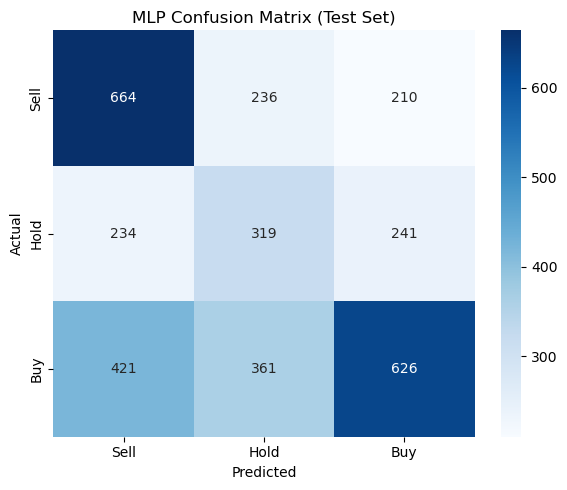

In [31]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

y_pred_probs = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_probs, axis=1)

label_names = ["Sell", "Hold", "Buy"]
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_names))

macro_f1 = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1 Score: {macro_f1:.4f}")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_names, yticklabels=label_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("MLP Confusion Matrix (Test Set)")
plt.tight_layout()
plt.savefig("eda/mlp_confusion_matrix.png", dpi=150)
plt.show()


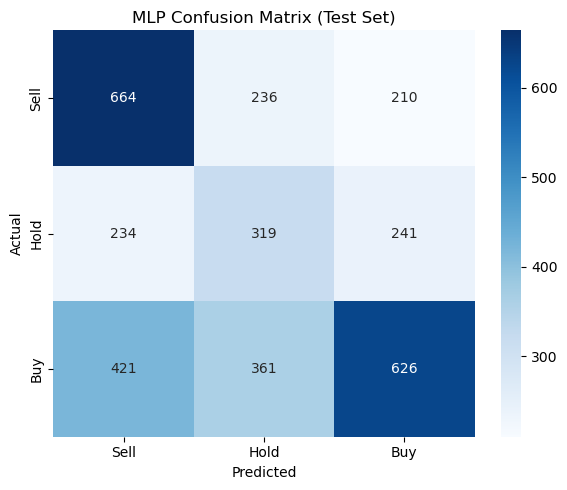

In [32]:
import os
os.makedirs("eda", exist_ok=True)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_names, yticklabels=label_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("MLP Confusion Matrix (Test Set)")
plt.tight_layout()
plt.savefig("eda/mlp_confusion_matrix.png", dpi=150)
plt.show()

In [34]:
import os
os.makedirs("models", exist_ok=True)

model.save("models/mlp_baseline.keras")

test_predictions_df = pd.DataFrame({
    "actual_label": [label_names[i] for i in y_test],
    "predicted_label": [label_names[i] for i in y_pred],
    "predicted_prob_sell": y_pred_probs[:, 0],
    "predicted_prob_hold": y_pred_probs[:, 1],
    "predicted_prob_buy": y_pred_probs[:, 2],
})
os.makedirs("mlp_baseline", exist_ok=True)
test_predictions_df.to_csv("mlp_baseline/predictions.csv", index=False)

print("Model and predictions saved.")
print(f"Final test accuracy: {test_accuracy:.4f}, Macro F1: {macro_f1:.4f}")

Model and predictions saved.
Final test accuracy: 0.4858, Macro F1: 0.4745


C:\Users\anish\AppData\Local\Temp\ipykernel_10200\3158773084.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sector_counts.values, y=sector_counts.index, palette="viridis")


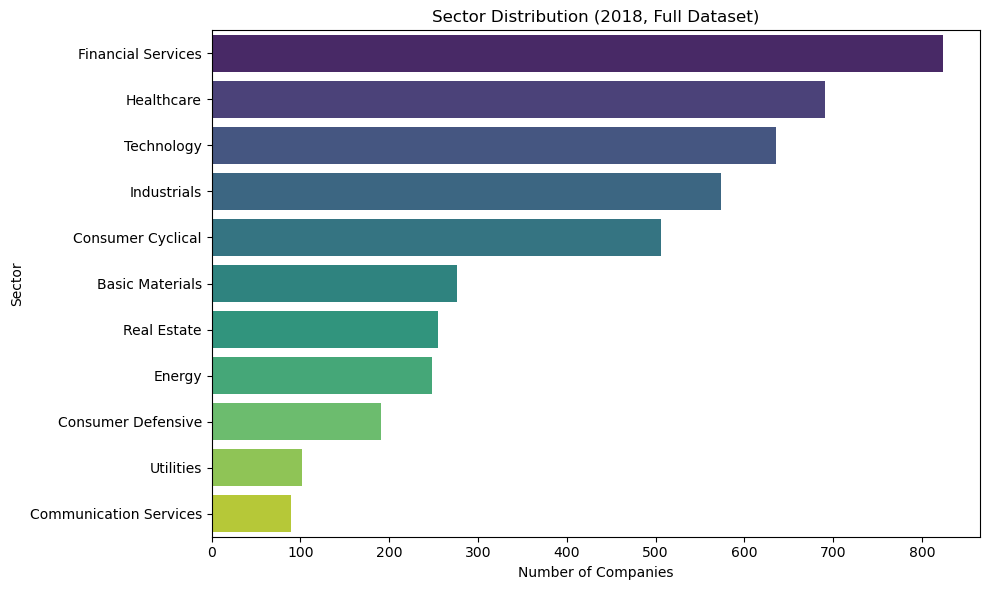

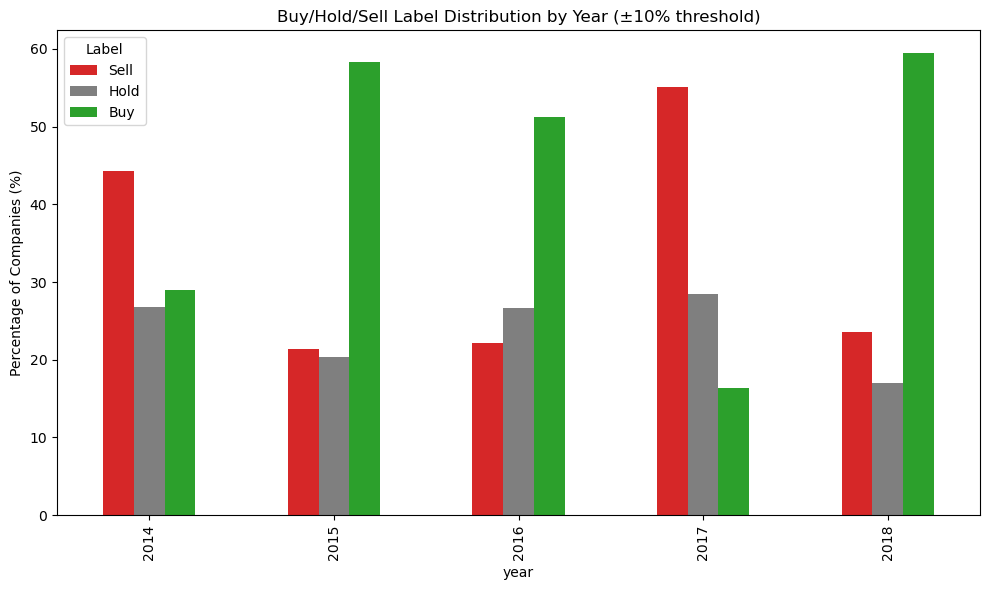

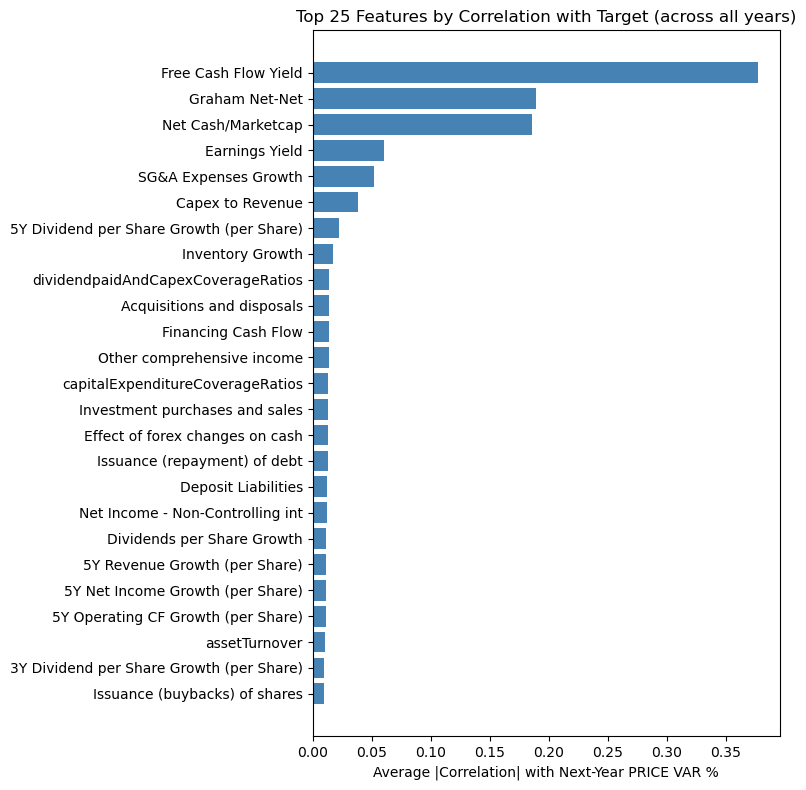

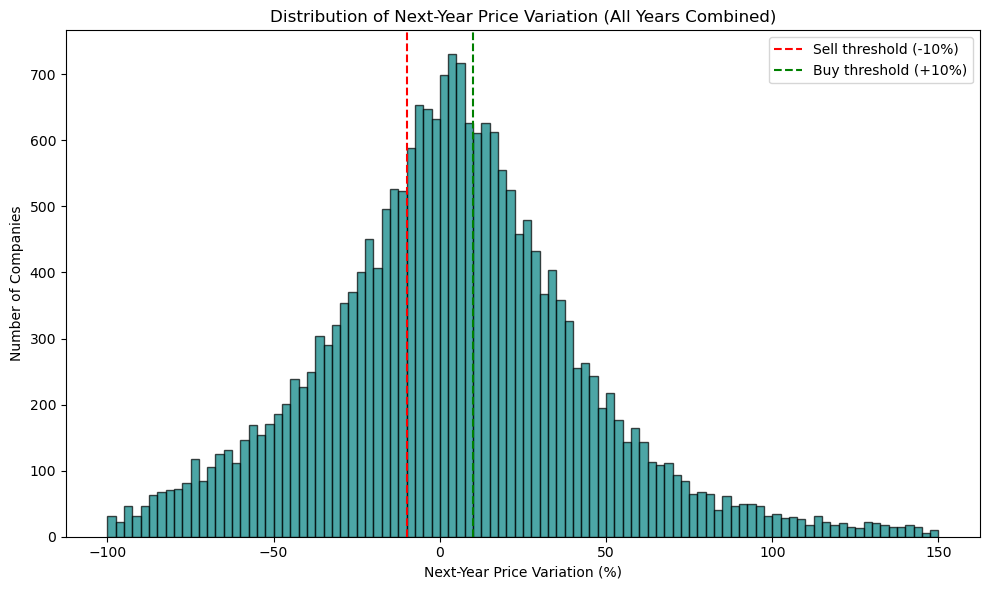

Saved 4 EDA figures to eda/ folder.


In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pandas as pd

os.makedirs("eda", exist_ok=True)

# 1. Sector distribution (2018, full dataset)
plt.figure(figsize=(10, 6))
sector_counts = imputed_frames["2018"][sector_col].value_counts()
sns.barplot(x=sector_counts.values, y=sector_counts.index, palette="viridis")
plt.xlabel("Number of Companies")
plt.ylabel("Sector")
plt.title("Sector Distribution (2018, Full Dataset)")
plt.tight_layout()
plt.savefig("eda/sector_distribution.png", dpi=150)
plt.show()

# 2. Buy/Hold/Sell label distribution by year
class_balance_data = []
for year, labels in y_label_by_year.items():
    counts = labels.value_counts(normalize=True) * 100
    for label, pct in counts.items():
        class_balance_data.append({"year": year, "label": label, "pct": pct})

class_balance_df = pd.DataFrame(class_balance_data)
pivot_df = class_balance_df.pivot(index="year", columns="label", values="pct")[["Sell", "Hold", "Buy"]]

plt.figure(figsize=(10, 6))
pivot_df.plot(kind="bar", ax=plt.gca(), color=["#d62728", "#7f7f7f", "#2ca02c"])
plt.ylabel("Percentage of Companies (%)")
plt.title("Buy/Hold/Sell Label Distribution by Year (±10% threshold)")
plt.legend(title="Label")
plt.tight_layout()
plt.savefig("eda/label_distribution_by_year.png", dpi=150)
plt.show()

# 3. Top 25 features by correlation with next-year PRICE VAR %
plt.figure(figsize=(8, 8))
top25 = top_features.head(25).sort_values("avg_abs_corr")
plt.barh(top25.index, top25["avg_abs_corr"], color="steelblue")
plt.xlabel("Average |Correlation| with Next-Year PRICE VAR %")
plt.title("Top 25 Features by Correlation with Target (across all years)")
plt.tight_layout()
plt.savefig("eda/feature_correlation_top25.png", dpi=150)
plt.show()

# 4. PRICE VAR % distribution (all years combined, with thresholds marked)
all_price_vars = []
for year, df in final_treated_frames.items():
    col = [c for c in df.columns if "PRICE VAR" in c.upper()][0]
    all_price_vars.extend(df[col].dropna().tolist())

plt.figure(figsize=(10, 6))
plt.hist(all_price_vars, bins=100, range=(-100, 150), color="teal", edgecolor="black", alpha=0.7)
plt.axvline(-10, color="red", linestyle="--", label="Sell threshold (-10%)")
plt.axvline(10, color="green", linestyle="--", label="Buy threshold (+10%)")
plt.xlabel("Next-Year Price Variation (%)")
plt.ylabel("Number of Companies")
plt.title("Distribution of Next-Year Price Variation (All Years Combined)")
plt.legend()
plt.tight_layout()
plt.savefig("eda/price_var_distribution.png", dpi=150)
plt.show()

print("Saved 4 EDA figures to eda/ folder.")

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow import keras

# --- Step 1: Reload pooled data EXACTLY as before, to reproduce an identical scaler ---
X_by_year_reloaded = {}
y_by_year_reloaded = {}
for year in ["2014", "2015", "2016", "2017", "2018"]:
    X_by_year_reloaded[year] = pd.read_csv(f"data_processed/checkpoints/X_{year}.csv")
    y_by_year_reloaded[year] = pd.read_csv(
        f"data_processed/checkpoints/y_label_encoded_{year}.csv"
    ).iloc[:, 0]

X_all = pd.concat([X_by_year_reloaded[y] for y in X_by_year_reloaded], ignore_index=True)
y_all = pd.concat([y_by_year_reloaded[y] for y in y_by_year_reloaded], ignore_index=True)

X_train, _, y_train, _ = train_test_split(
    X_all, y_all, test_size=0.30, random_state=42, stratify=y_all
)

scaler = StandardScaler()
scaler.fit(X_train)  # identical to the original fit, since data + split + seed match exactly

# --- Step 2: Recover ticker for each year by realigning with the treated checkpoint ---
final_feature_cols = X_by_year_reloaded["2018"].columns.tolist()

ticker_keyed_features = {}
for year in ["2014", "2015", "2016", "2017", "2018"]:
    treated_df = pd.read_csv(f"data_processed/checkpoints/treated_{year}.csv", index_col=0)
    X_year = X_by_year_reloaded[year].copy()
    
    assert len(treated_df) == len(X_year), f"Row count mismatch in {year} — do not proceed blindly"
    
    X_year["ticker"] = treated_df.index.values
    X_year["year"] = year
    ticker_keyed_features[year] = X_year

# --- Step 3: Filter to the 22 shortlisted companies only ---
shortlist = pd.read_csv("data_processed/selected_companies.csv")
shortlist_tickers = shortlist["ticker"].tolist()

shortlist_rows = []
for year, df in ticker_keyed_features.items():
    subset = df[df["ticker"].isin(shortlist_tickers)]
    shortlist_rows.append(subset)

shortlist_features = pd.concat(shortlist_rows, ignore_index=True)
print(f"Recovered {len(shortlist_features)} rows for the 22-company shortlist across 5 years")
print(shortlist_features[["ticker", "year"]].drop_duplicates().shape)

# --- Step 4: Predict using the ORIGINAL trained model + this correctly-fit scaler ---
model = keras.models.load_model("models/mlp_baseline.keras")

X_shortlist_scaled = scaler.transform(shortlist_features[final_feature_cols])
pred_probs = model.predict(X_shortlist_scaled)
pred_labels = np.argmax(pred_probs, axis=1)

label_names = ["Sell", "Hold", "Buy"]
ticker_keyed_predictions = pd.DataFrame({
    "ticker": shortlist_features["ticker"],
    "year": shortlist_features["year"],
    "predicted_label": [label_names[i] for i in pred_labels],
    "predicted_prob_sell": pred_probs[:, 0],
    "predicted_prob_hold": pred_probs[:, 1],
    "predicted_prob_buy": pred_probs[:, 2],
})

ticker_keyed_predictions.to_csv("mlp_baseline/predictions_by_company.csv", index=False)
print("Saved ticker-keyed predictions for Member 3.")
print(ticker_keyed_predictions.head(10))

Recovered 110 rows for the 22-company shortlist across 5 years
(110, 2)
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Saved ticker-keyed predictions for Member 3.
  ticker  year predicted_label  predicted_prob_sell  predicted_prob_hold  \
0   POST  2014            Sell             0.516228             0.195260   
1   JBSS  2014            Sell             0.389736             0.358813   
2   AXTA  2014             Buy             0.200318             0.272935   
3    UAN  2014            Hold             0.370357             0.407525   
4   PCRX  2014            Sell             0.463629             0.230461   
5   CLDX  2014            Sell             0.624608             0.116295   
6   APTV  2014            Hold             0.210585             0.463180   
7    VAC  2014            Sell             0.386331             0.319897   
8   ASPS  2014             Buy             0.256859             0.275093   
9   ULBI  2014            Sell             0.366140             0.364329   

   predi